# Simulations light inter

In [1]:
from __future__ import annotations

import math
import os
import sys
import time as t
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

sys.path.append(".") 
from plot_outputs import *

sys.path.append("../data") 
from archi_dict import archi_sorghum as archi_1
from archi_dict import archi_maize as archi_2

# from openalea.archicrop.display import build_scene, display_scene  # noqa: F401
from openalea.archicrop.simulation import compute_extinction_coef, concat_usm
# from openalea.plantgl.all import Color3, Material, Scene  # noqa: F401


# %gui qt

In [2]:
stics_color = "orange"
archicrop_color = "green"

In [3]:
tec_file_xml='../data/usms_STICS/v10/02NT18SorgV2D1_tec.xml'
plt_file_xml='../data/usms_STICS/v10/plant/sorgho_imp_M_v10_plt.xml'
stics_output_file='../data/usms_STICS/v10/mod_s02NT18SorgV2D1.sti'
weather_file = '../data/usms_STICS/v10/ntarla_corr.2018'
location = {  
'longitude': 3.87,
'latitude': 12.58,
'altitude': 800,
'timezone': 'Europe/Paris'}

In [4]:
n = 0
file = f"../simulations_ArchiCrop/results_light_inter_{n}.nc"
ds = xr.open_dataset(file)
print(len(ds.realized_la.values[0][0][0][0]), len(ds.realized_la.values[0][0][1][0]))

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\ArchiCrop\\simulations_ArchiCrop\\results_light_inter_0.nc'

In [86]:
def open_ds(n_cpu):
    file_list = []
    for cpu in range(n_cpu):
        file_list.append(f"../simulations_ArchiCrop/results_light_inter_{cpu}.nc")
    ds = concat_usm(file_list)
    return ds

def open_ds_usms(usms):
    file_list = []
    for usm in usms:
        file_list.append(f"../simulations_ArchiCrop/results_light_inter_usm_{usm}.nc") ##########################################3
    ds = concat_usm(file_list)
    return ds


In [87]:
usms = [1,2,3,4,5,6,10,12,14,16,18,22,24,26]
id_usm = [f"usm_{i}" for i in usms]
usms_dict = dict(zip(range(len(usms)),usms))
n_cpu = len(usms)
ds = open_ds_usms(usms_dict.values())
ds

<xarray.Dataset> Size: 2MB
Dimensions:                 (usm: 14, algo: 2, plant: 2, date: 365, id: 1)
Coordinates:
  * usm                     (usm) object 112B 'usm_1' 'usm_2' ... 'usm_26'
  * algo                    (algo) object 16B '2.5D' 'Beer'
  * plant                   (plant) object 16B 'maize' 'sorghum'
  * date                    (date) object 3kB '2018-01-01' ... '2018-12-31'
  * id                      (id) int32 4B 0
Data variables: (12/42)
    thermal_time            (usm, algo, plant, date) float64 164kB nan ... nan
    lai_stics               (usm, algo, plant, date) float64 164kB nan ... nan
    sen_lai_stics           (usm, algo, plant, date) float64 164kB nan ... nan
    height_stics            (usm, algo, plant, date) float64 164kB nan ... nan
    inc_par                 (usm, algo, plant, date) float64 164kB nan ... nan
    abs_par_stics           (usm, algo, plant, date) float64 164kB nan ... nan
    ...                      ...
    reduction_factor        (usm, algo, plant, id) float64 448B 1.0 0.5 ... 0.5
    tropism_coefficient     (usm, algo, plant, id) float64 448B 0.05 ... 0.12
    leaf_lifespan           (usm, algo, plant, id) float64 448B 200.0 ... 280.0
    leaf_lifespan_early     (usm, algo, plant, id) float64 448B 160.0 ... 224.0
    nb_phy                  (usm, algo, plant, id) int32 224B 20 16 20 ... 20 16
    domain_area             (usm, algo) float64 224B 1.28 1.28 ... 0.64 0.64

In [88]:
ds.domain_area.values[0][0]

np.float64(1.28)

In [91]:
usms_str = ds.usm.values
algos = ds.algo.values
plants = ds.plant.values
dates = ds.date.values[:-1]
# dates = pd.to_datetime(dates)
# dates = dates.strftime('%Y-%m-%d')

thermal_time = {usm: {algo: {plant: ds.thermal_time.values[u][a][p][1:] for p,plant in enumerate(plants) if ds.thermal_time.values[u][a][p] is not None} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
leaf_area_plant = {usm: {algo: {plant: ds.lai_stics.values[u][a][p][1:] for p,plant in enumerate(plants) if ds.lai_stics.values[u][a][p] is not None} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
sen_leaf_area_plant = {usm: {algo: {plant: ds.sen_lai_stics.values[u][a][p][1:] for p,plant in enumerate(plants) if ds.sen_lai_stics.values[u][a][p] is not None} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
height_canopy = {usm: {algo: {plant: ds.height_stics.values[u][a][p][1:] for p,plant in enumerate(plants) if ds.height_stics.values[u][a][p] is not None} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
par_incident = {usm: {algo: {plant: ds.inc_par.values[u][a][p][1:] for p,plant in enumerate(plants) if ds.inc_par.values[u][a][p] is not None} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
par_stics = {usm: {algo: {plant: ds.abs_par_stics.values[u][a][p][1:] for p,plant in enumerate(plants) if ds.abs_par_stics.values[u][a][p] is not None} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
density = {usm: {algo: {plant: ds.density.values[u][a][p][10] for p,plant in enumerate(plants) if ds.density.values[u][a][p] is not None} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
domain_area = {usm: {algo: ds.domain_area.values[u][a] for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}

realized_la = {usm: {algo: {plant: ds.realized_la.values[u][a][p][0][:-1] for p,plant in enumerate(plants) if ds.realized_la.values[u][a][p][0] is not None} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
realized_h = {usm: {algo: {plant: ds.realized_h.values[u][a][p][0][:-1] for p,plant in enumerate(plants) if ds.realized_h.values[u][a][p][0] is not None} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}

nrj_crop = {usm: {algo: {plant: [nrj/par_incident[usm][algo][plant][t]/domain_area[usm][algo] for t,nrj in enumerate(ds.nrj_per_leaf.values[u][a][p][0][:-1])] for p,plant in enumerate(plants) if ds.nrj_per_leaf.values[u][a][p][0] is not None} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}


In [97]:
nrj_crop

{'usm_1': {'2.5D': {'maize': [np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.float64(nan),
    np.f

In [94]:
par_incident['usm_1']['Beer']['sorghum']

array([    nan,     nan,     nan,     nan,     nan,     nan,     nan,
           nan,     nan,     nan,     nan,     nan,     nan,     nan,
           nan,     nan,     nan,     nan,     nan,     nan,     nan,
           nan,     nan,     nan,     nan,     nan,     nan,     nan,
           nan,     nan,     nan,     nan,     nan,     nan,     nan,
           nan,     nan,     nan,     nan,     nan,     nan,     nan,
           nan,     nan,     nan,     nan,     nan,     nan,     nan,
           nan,     nan,     nan,     nan,     nan,     nan,     nan,
           nan,     nan,     nan,     nan,     nan,     nan,     nan,
           nan,     nan,     nan,     nan,     nan,     nan,     nan,
           nan,     nan,     nan,     nan,     nan,     nan,     nan,
           nan,     nan,     nan,     nan,     nan,     nan,     nan,
           nan,     nan,     nan,     nan,     nan,     nan,     nan,
           nan,     nan,     nan,     nan,     nan,     nan,     nan,
           nan,     

In [60]:
from openalea.archicrop.stics_io import read_doe_intercrop

plant_1 = "sorghum"
plant_2 = "maize"

row_orientation_values = {
"N-S" : 0,
"E-W" : math.pi / 2
}

interrow_distance_per_species = {
"sorghum" : {
    "high" : 0.8,
    "middle" : 0.4,
    "low" : 0.2
},
"maize_trop" : {
    "high" : 0.8,
    "middle" : 0.4,
    "low" : 0.2
}
}

n_rows_per_species = {
"sorghum" : {
    "one" : 1, # For non-strip, this is just one row
    "high" : 6,
    "middle" : 4,
    "low" : 2
},
"maize_trop" : {
    "one" : 1,
    "high" : 6,
    "middle" : 4,
    "low" : 2
}
}

intrarow_distance_per_species = {
"sorghum" : {
    "high" : 0.8,
    "middle" : 0.4, # ~6 plants per m2 with 0.4m interrow distance, gives 0.41m intrarow distance
    "low" : 0.2
},
"maize_trop" : {
    "high" : 0.8,
    "middle" : 0.4,
    "low" : 0.2
}
}

doe_file = "../data/usms_STICS/v11_IC_light/doe.csv"
doe = read_doe_intercrop(doe_file)

doe_adapt = {}

for usm,spat_conf in doe.items():
    if usm in id_usm:
        spat_conf["row_orientation"] = row_orientation_values[spat_conf["row_orientation"]]
        spat_conf["interrow_distance_principal"] = interrow_distance_per_species[spat_conf["species_principal"]][spat_conf["interrow_distance_principal"]]
        spat_conf["interrow_distance_secondary"] = interrow_distance_per_species[spat_conf["species_secondary"]][spat_conf["interrow_distance_secondary"]]
        spat_conf["n_rows_principal"] = n_rows_per_species[spat_conf["species_principal"]][spat_conf["n_rows_principal"]]
        spat_conf["n_rows_secondary"] = n_rows_per_species[spat_conf["species_secondary"]][spat_conf["n_rows_secondary"]]
        spat_conf["intrarow_distance"] = intrarow_distance_per_species[spat_conf["species_principal"]][spat_conf["intrarow_distance"]]

        doe_adapt[usm] = {}

        for algo in density[usm].keys():

            doe_adapt[usm][algo] = {
                "density_1" : density[usm][algo][plant_1],
                "density_2" : density[usm][algo][plant_2],
                "inter_row_1" : spat_conf["interrow_distance_principal"],
                "inter_row_2" : spat_conf["interrow_distance_secondary"],
                "width" : 2 * spat_conf["interrow_distance_principal"] if spat_conf["design"] == "intercrop mixed" else (spat_conf["n_rows_principal"]+1) * spat_conf["interrow_distance_principal"] + (spat_conf["n_rows_secondary"]-1) * spat_conf["interrow_distance_secondary"],
                "length" : 2 * spat_conf["intrarow_distance"] if spat_conf["design"] == "intercrop mixed" else spat_conf["intrarow_distance"],
                "nb_rows_1" : spat_conf["n_rows_principal"],
                "nb_rows_2" : spat_conf["n_rows_secondary"]
            }

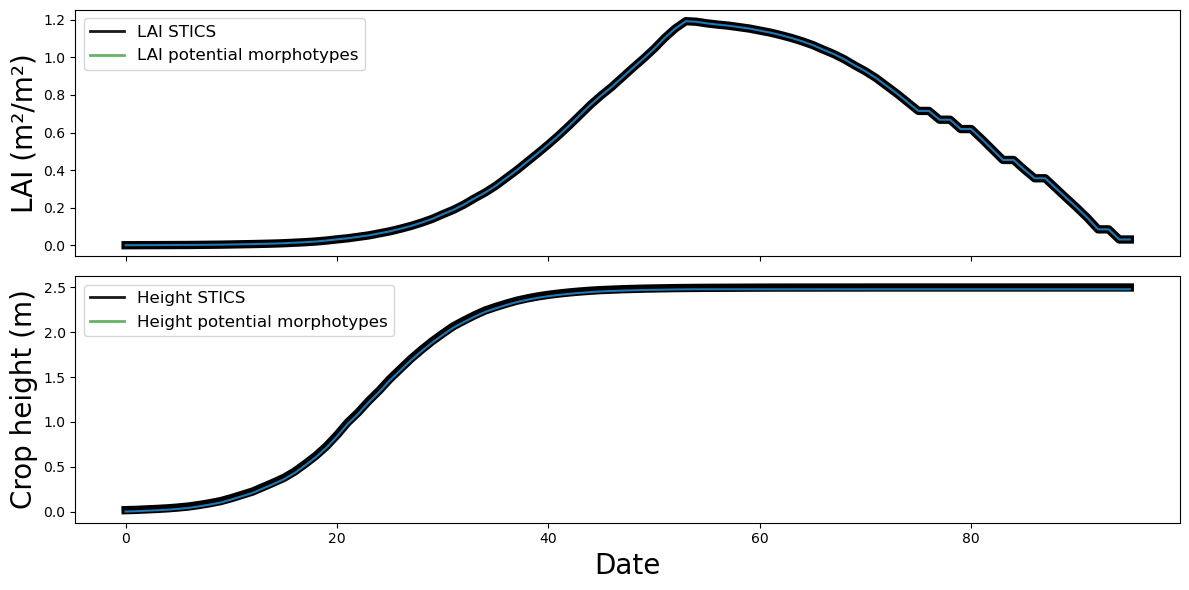

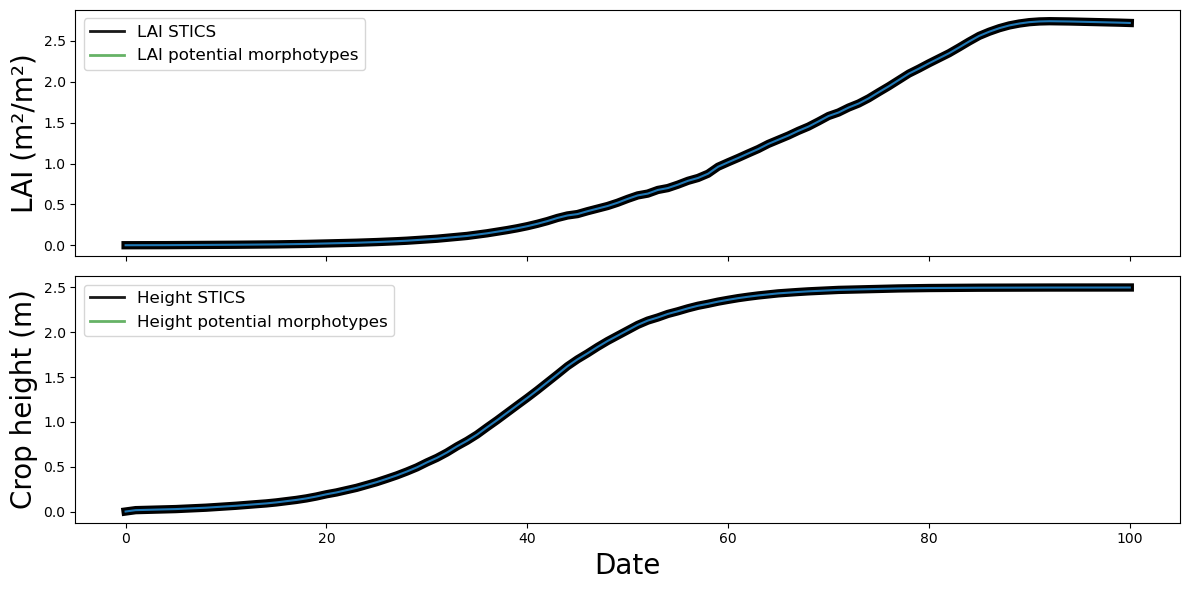

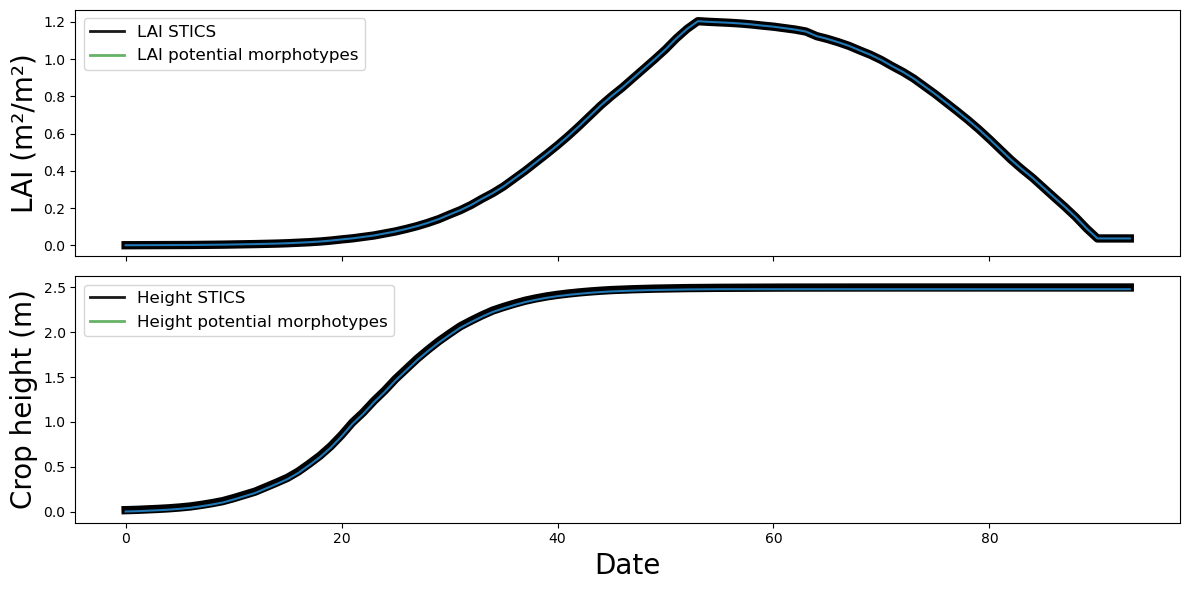

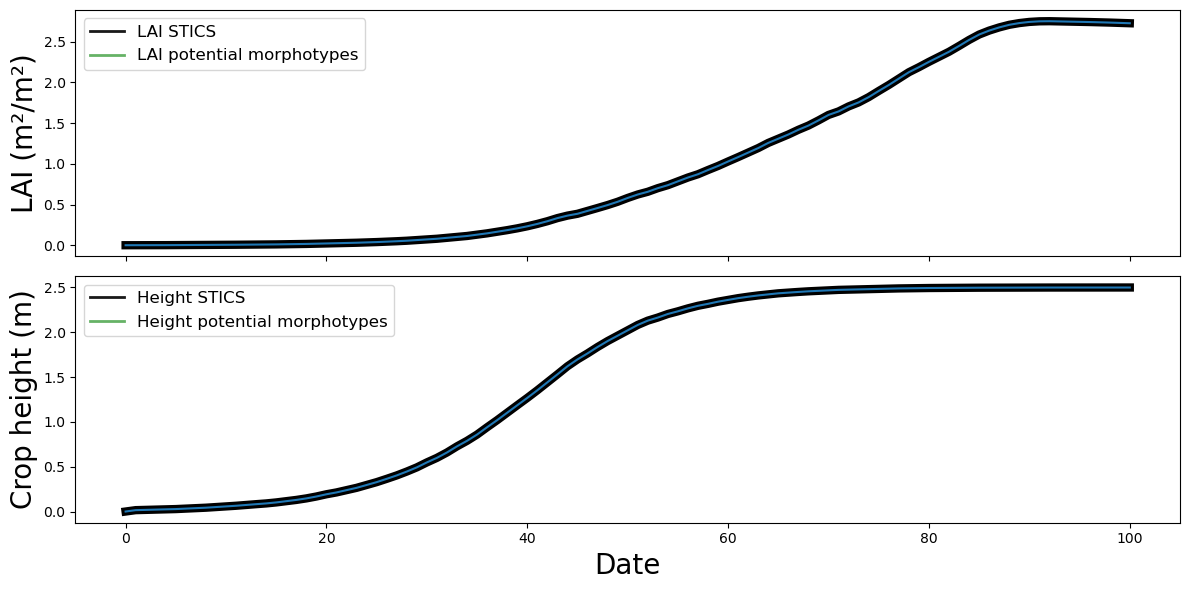

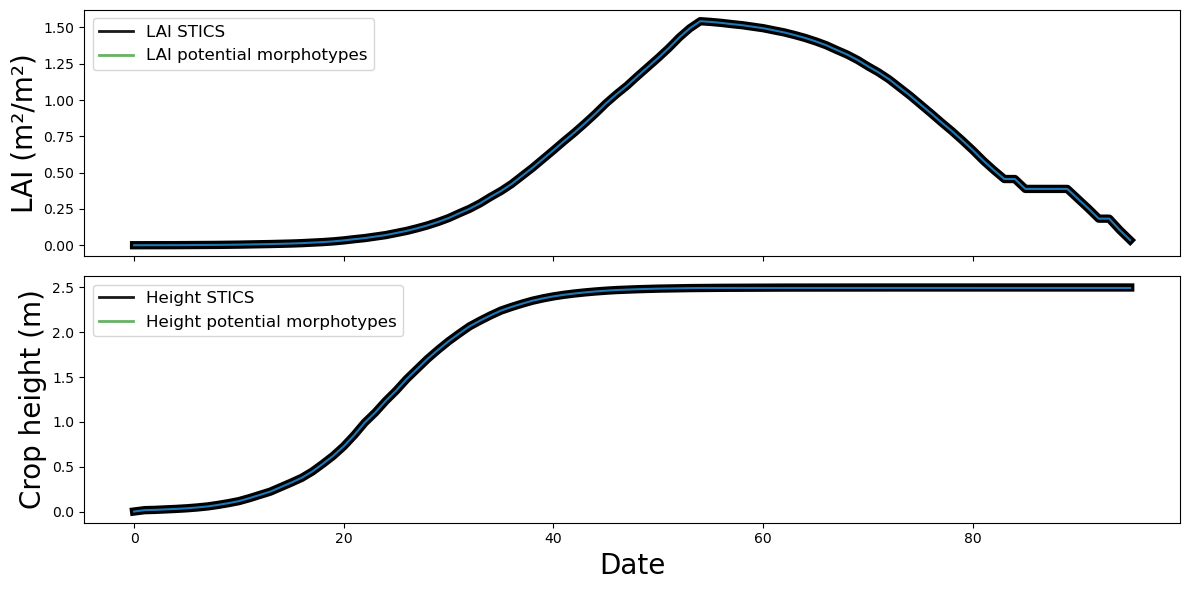

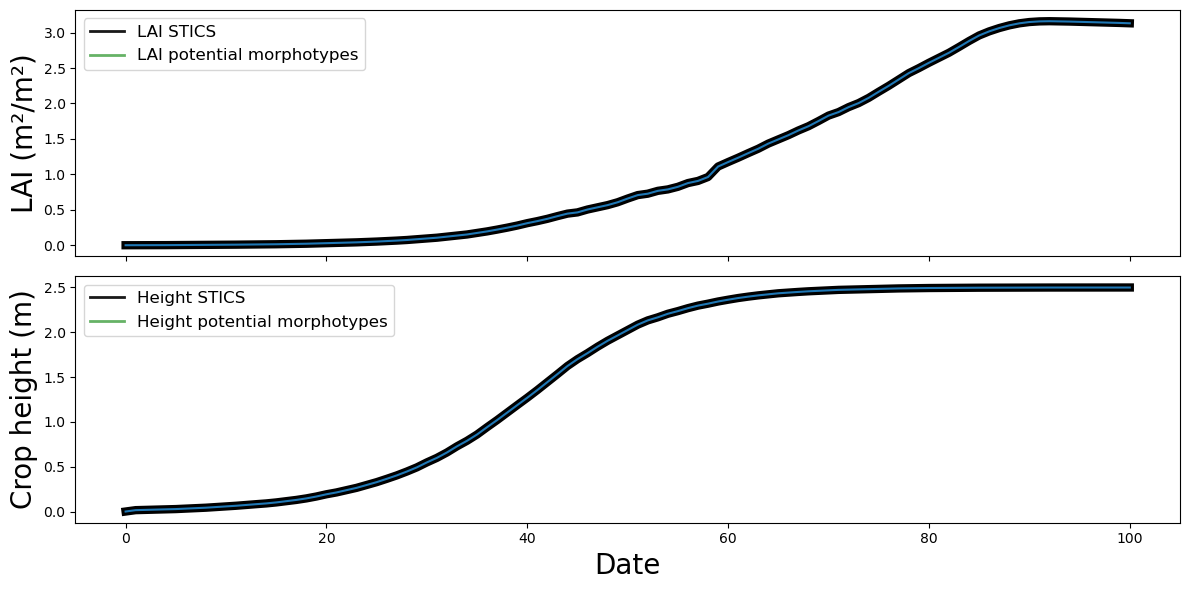

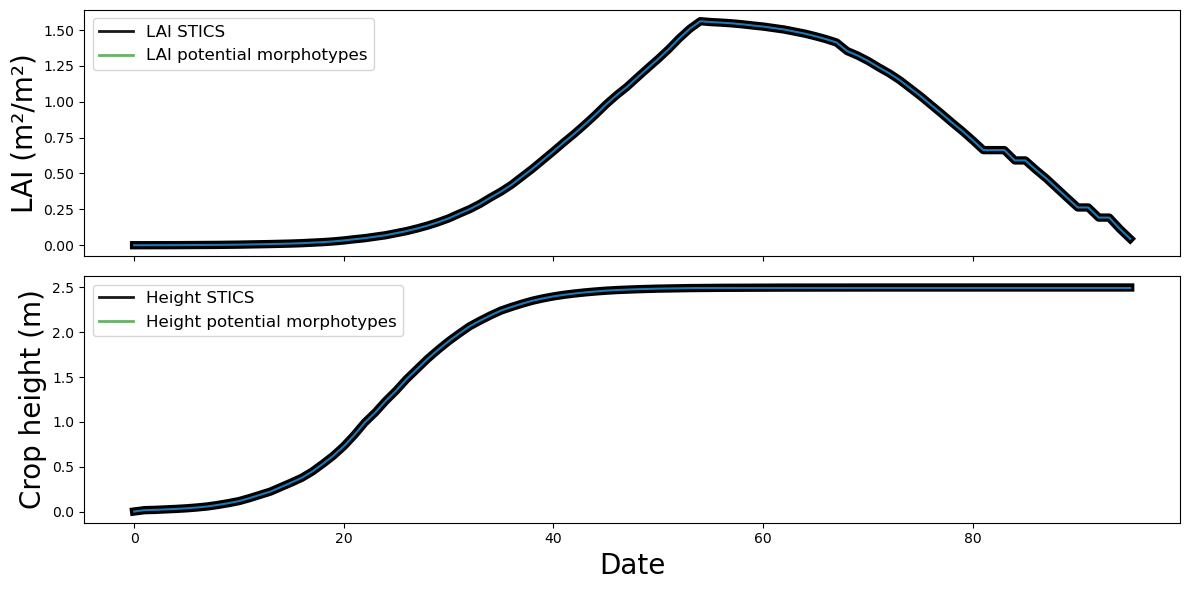

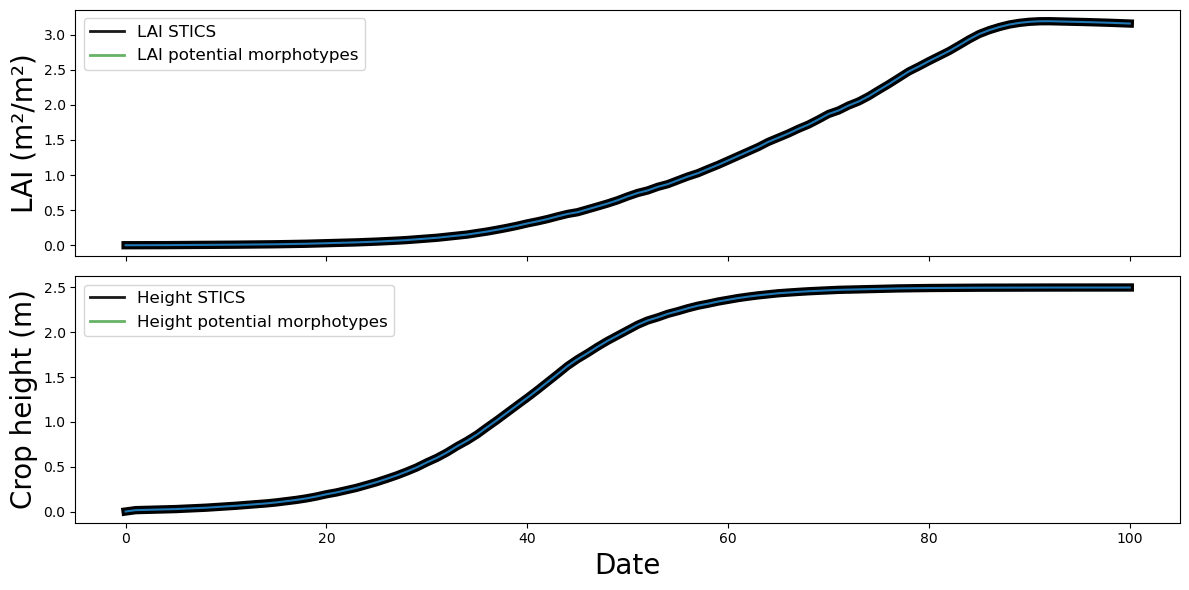

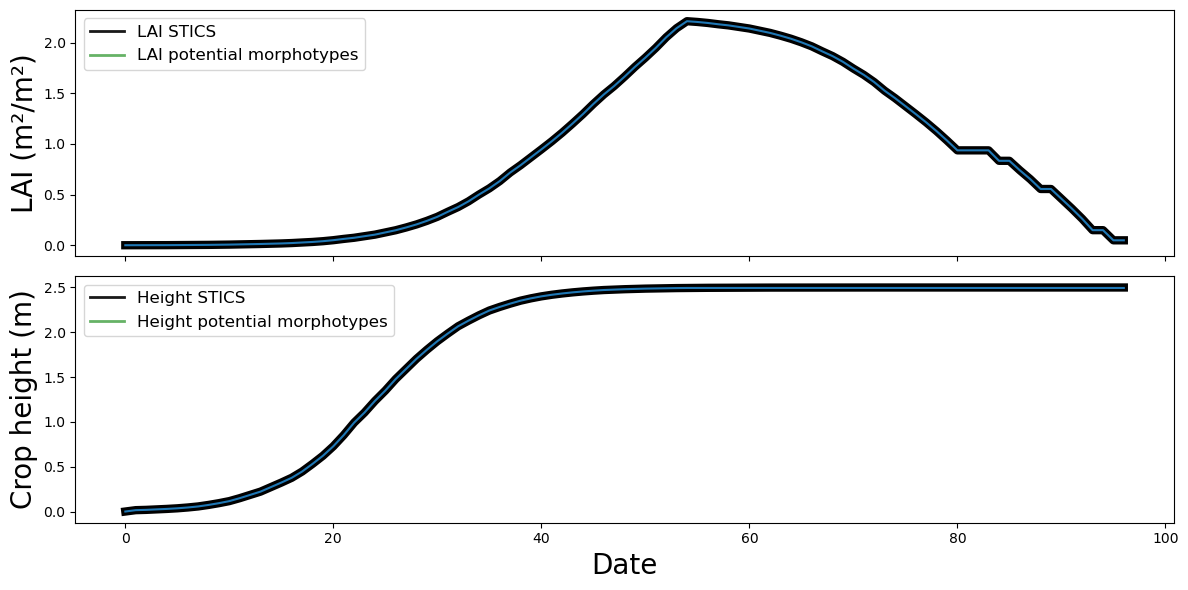

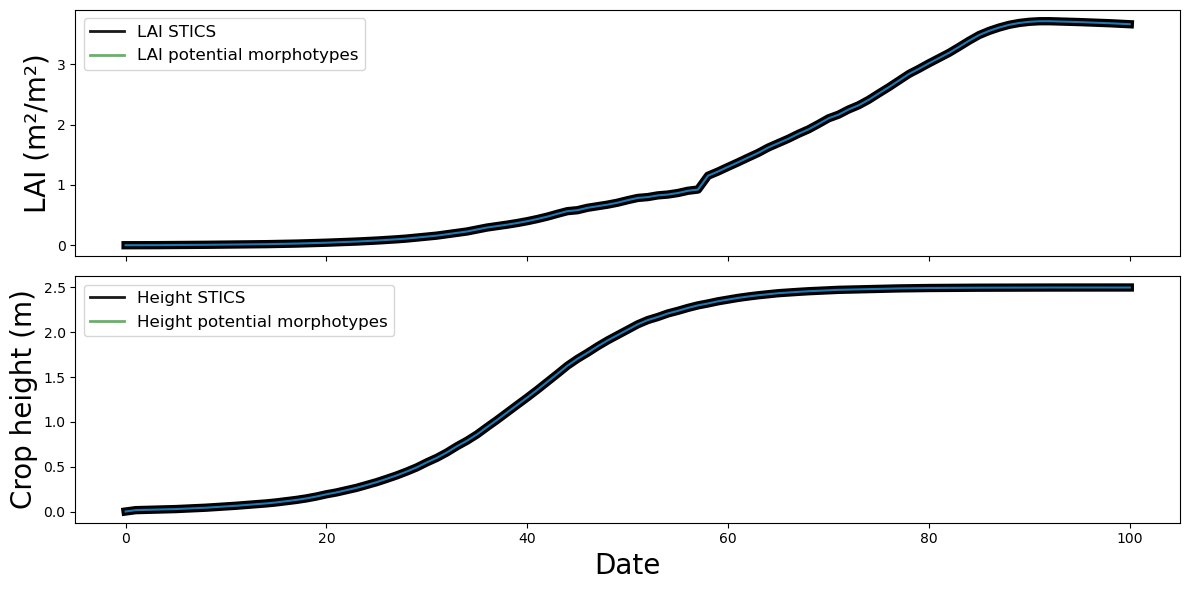

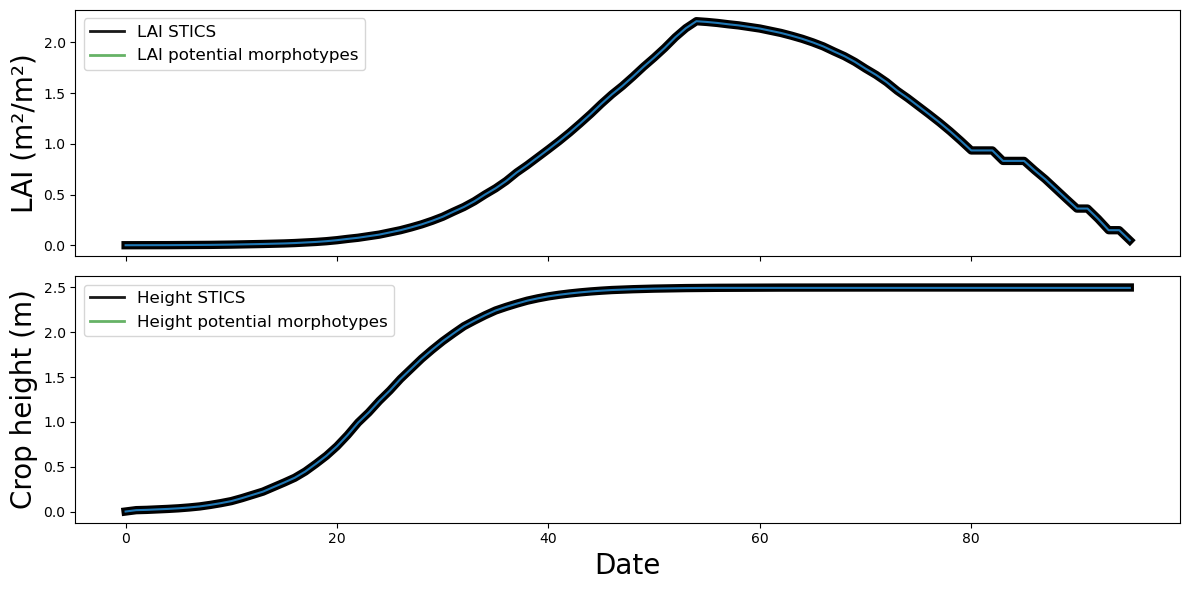

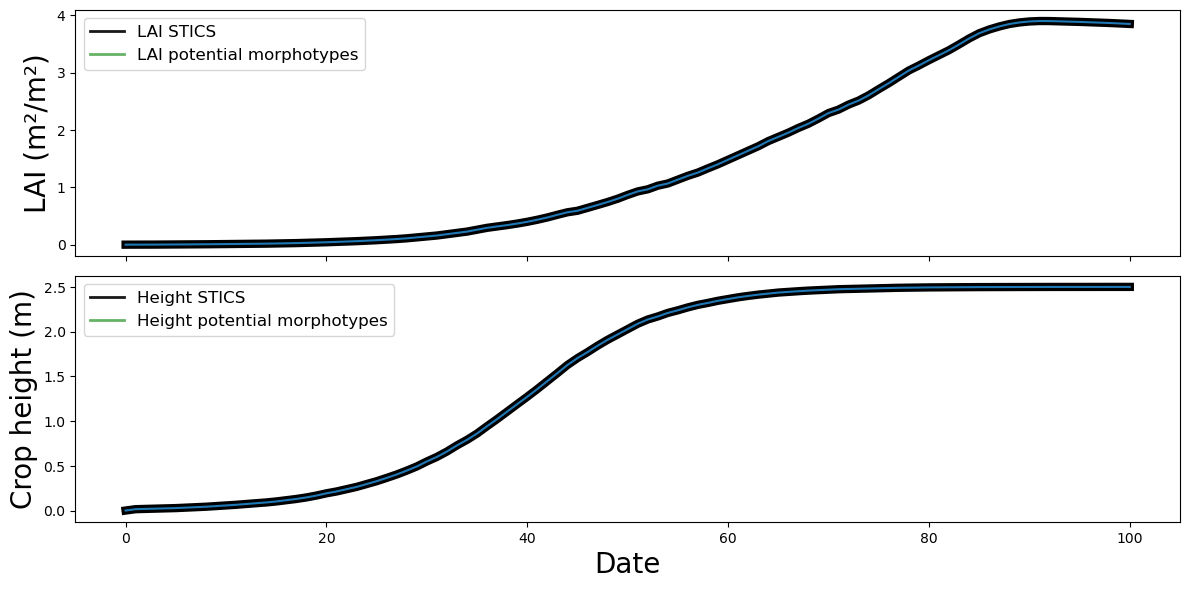

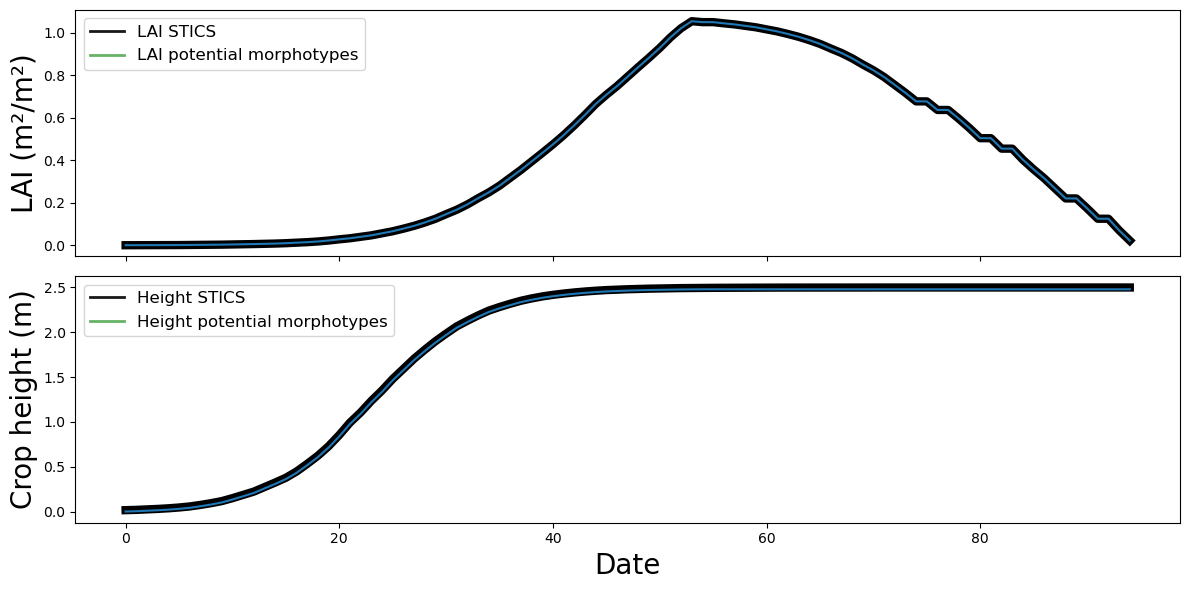

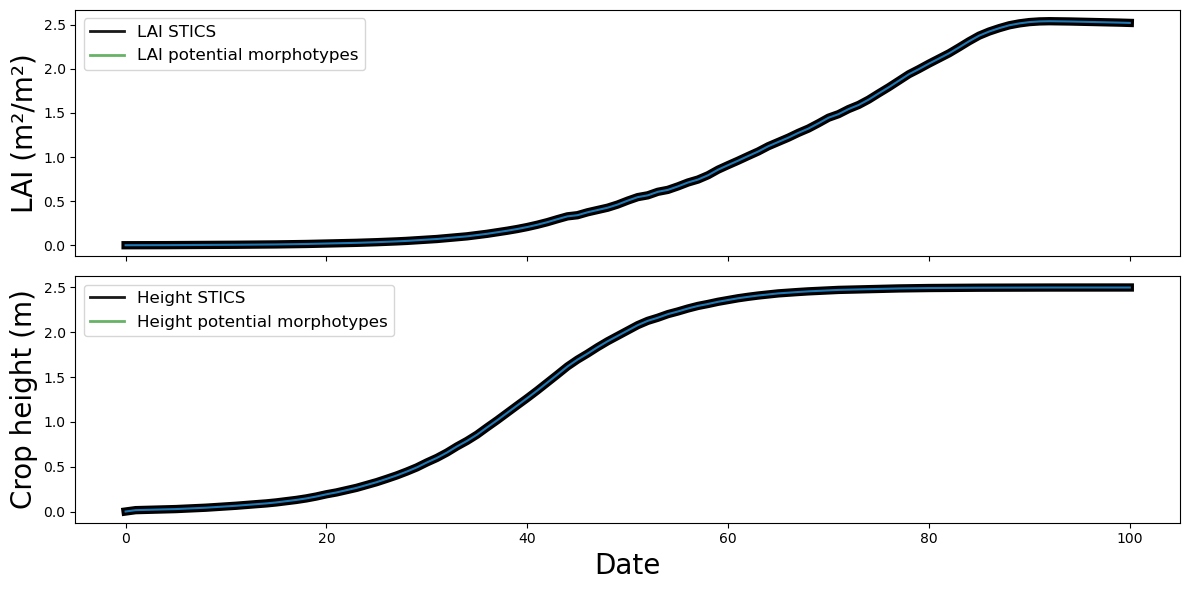

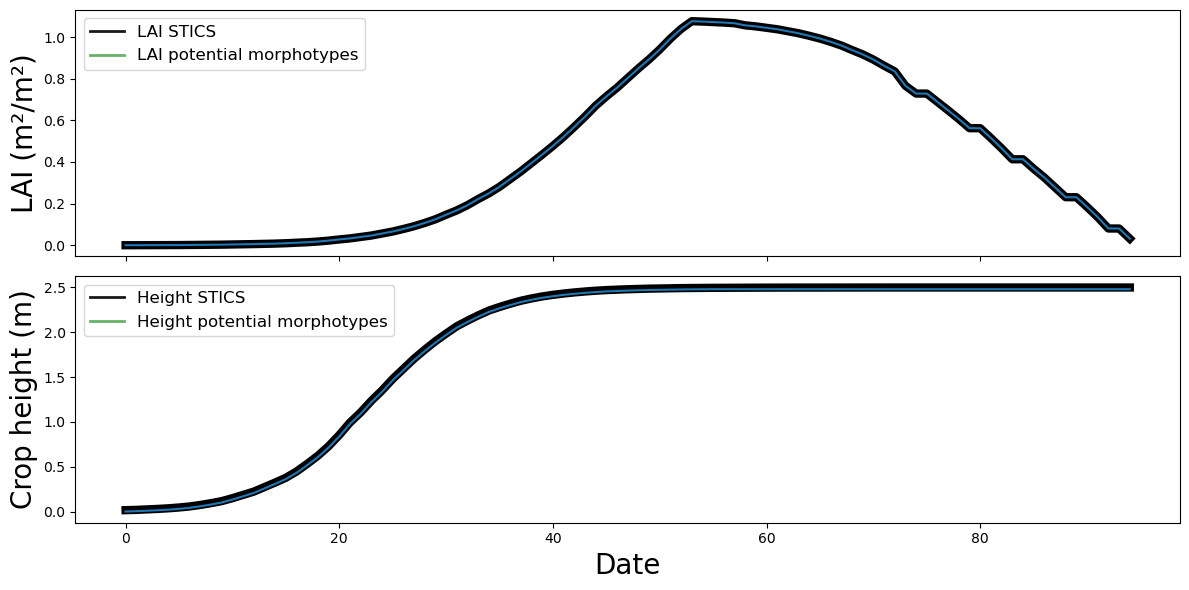

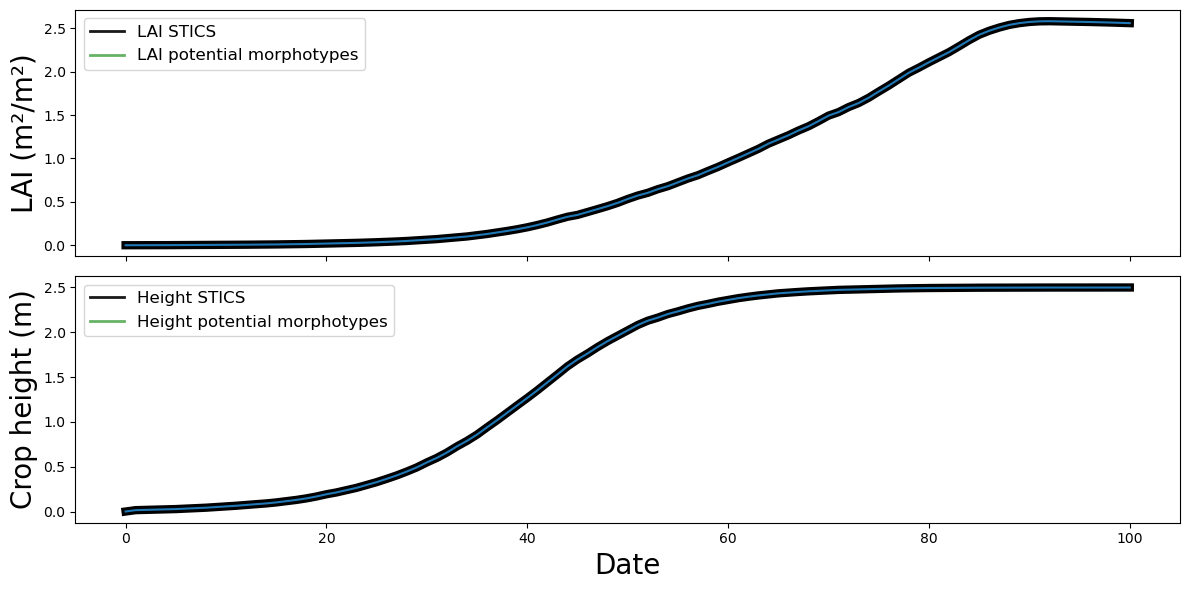

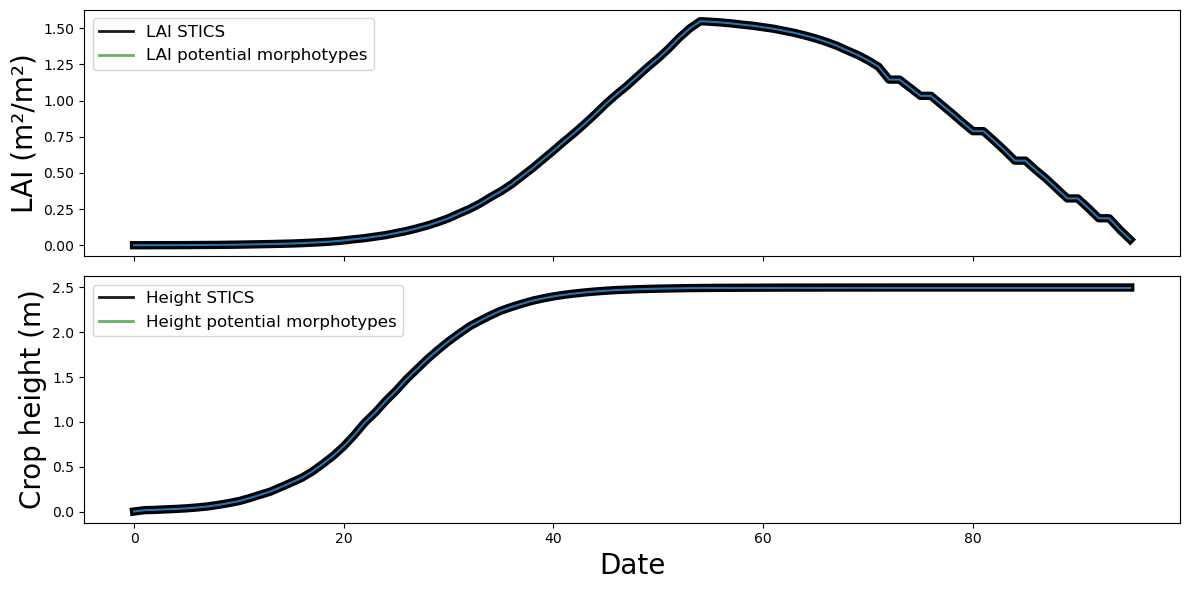

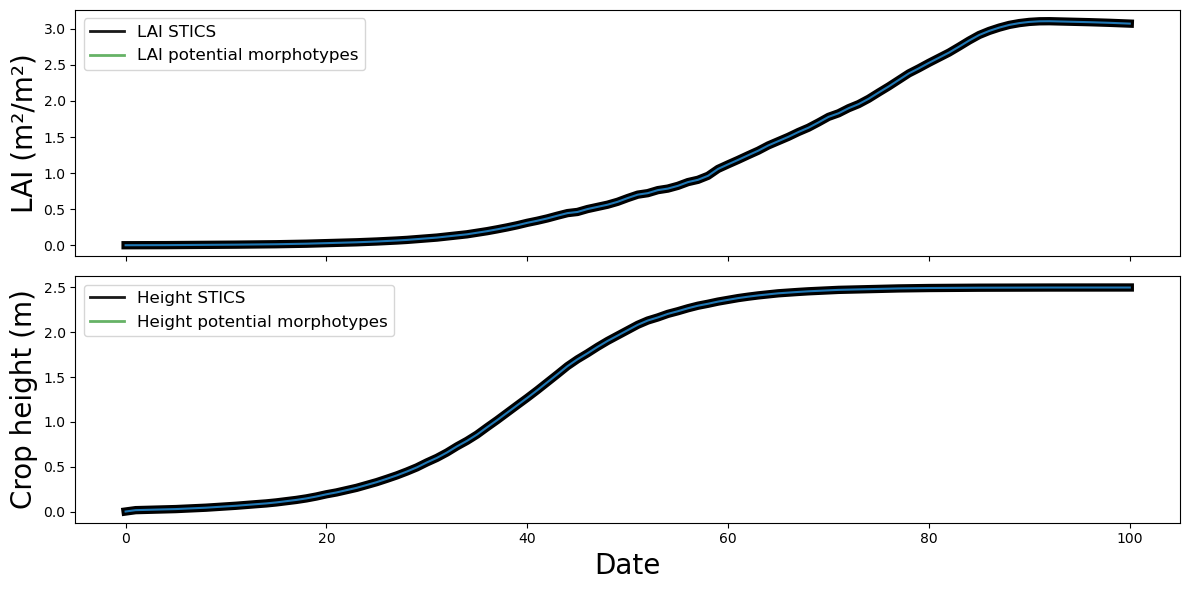

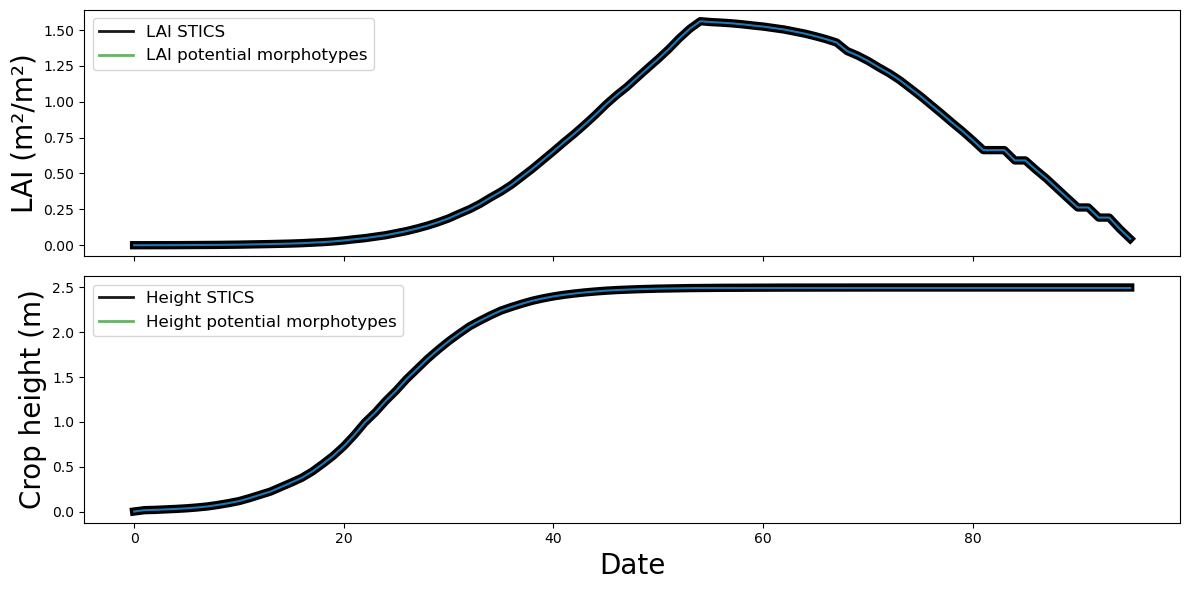

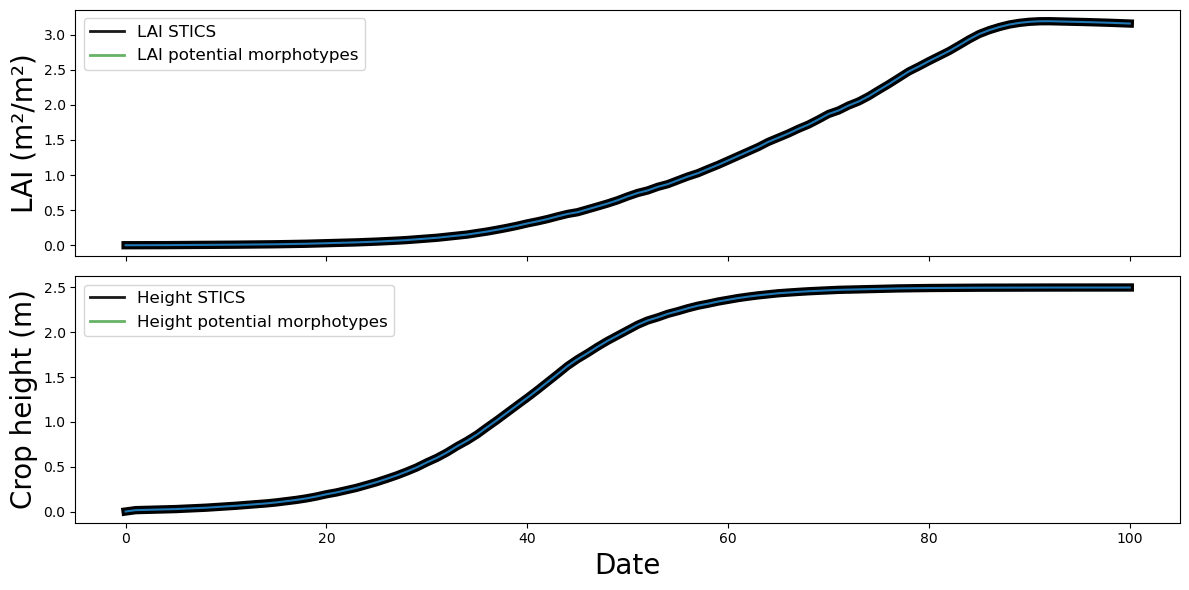

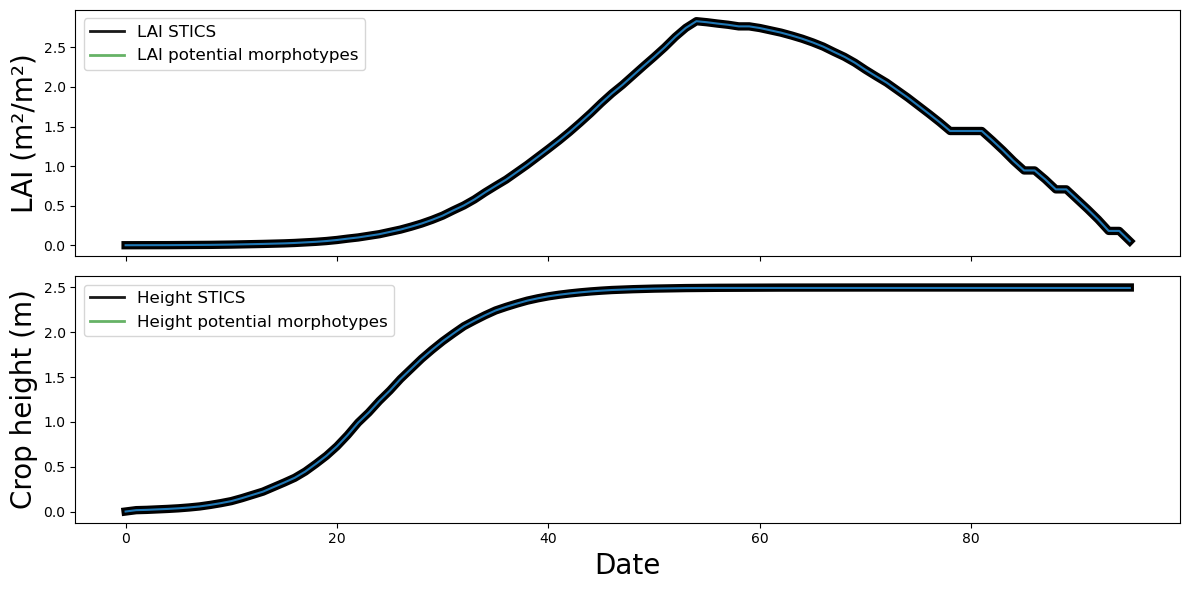

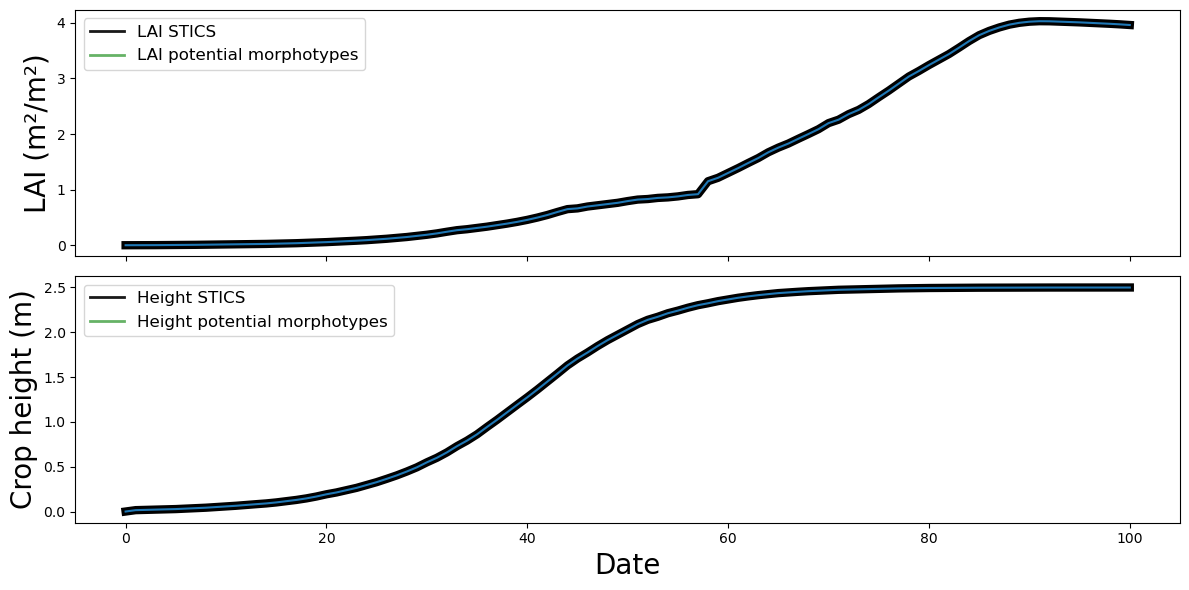

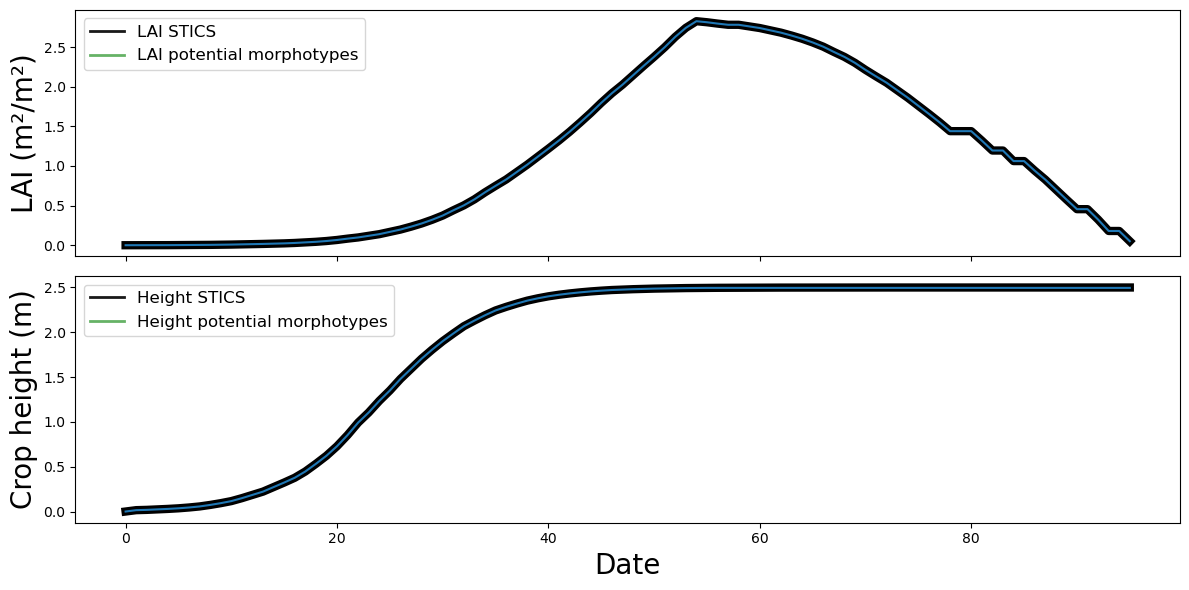

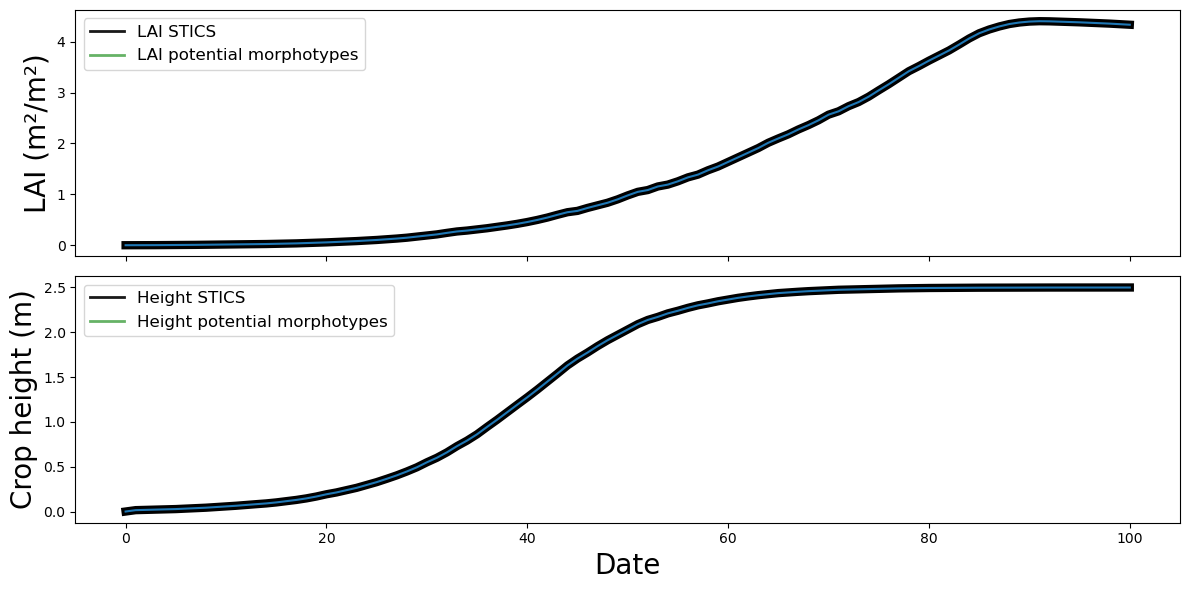

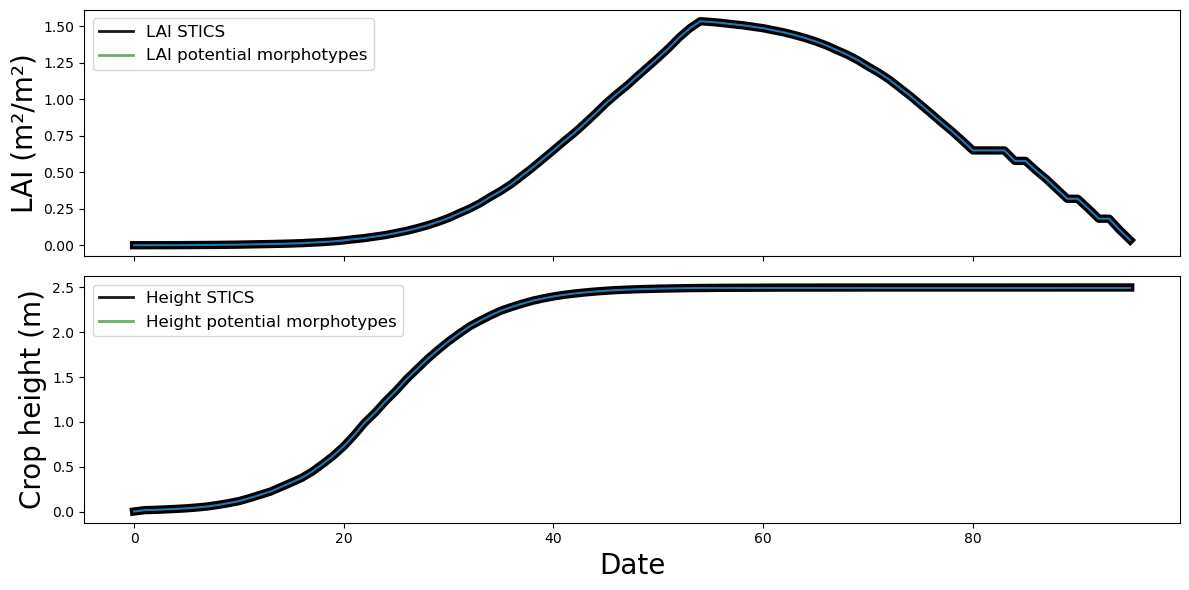

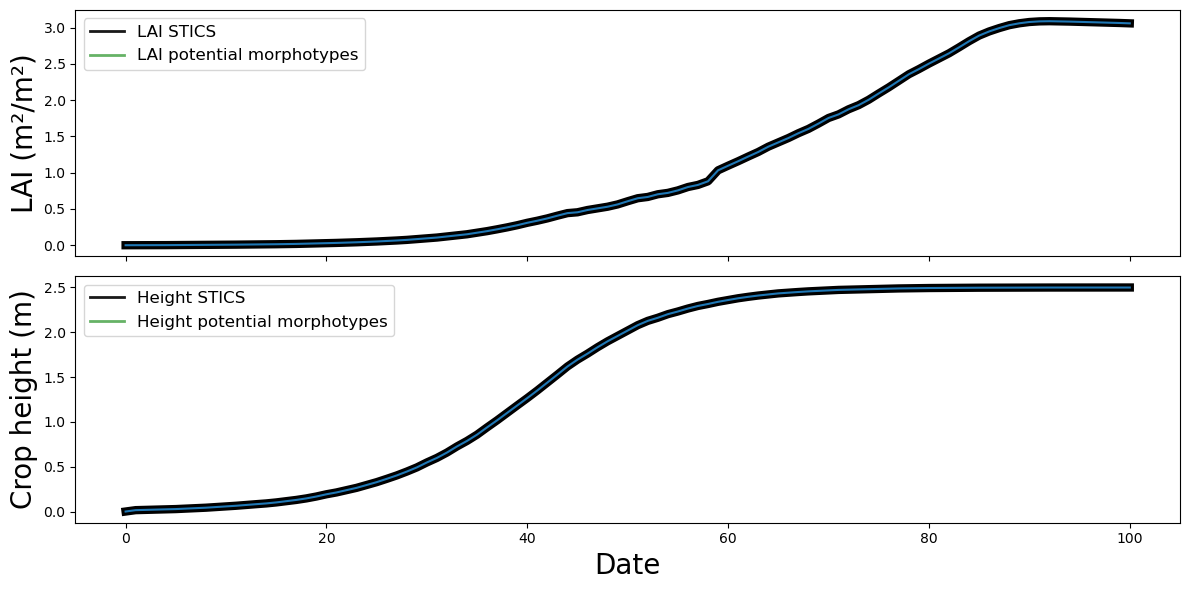

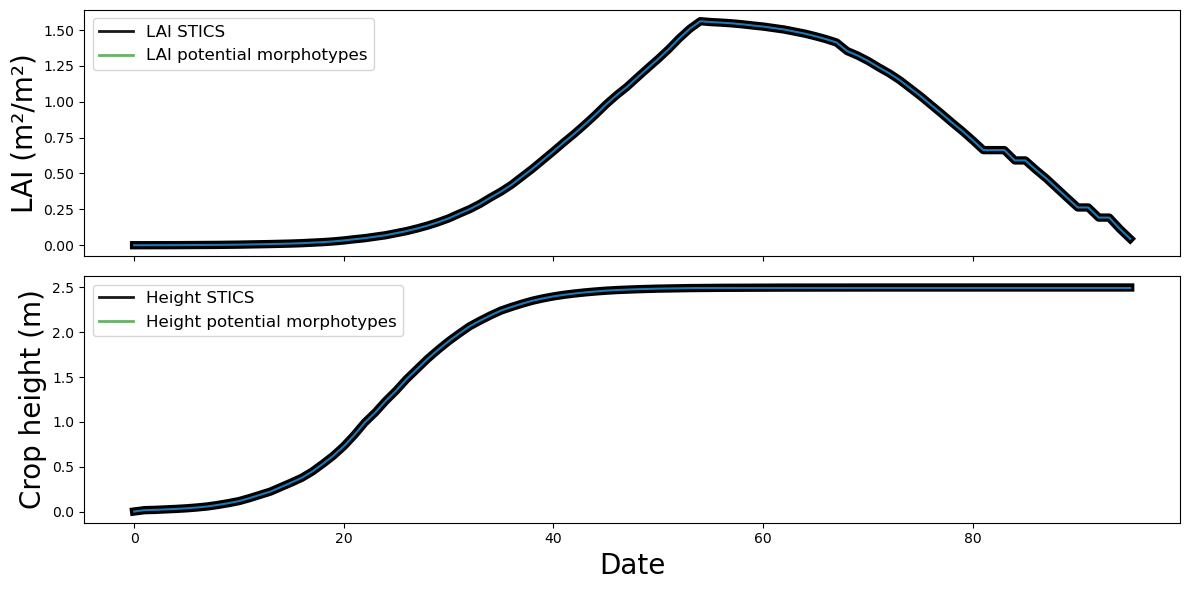

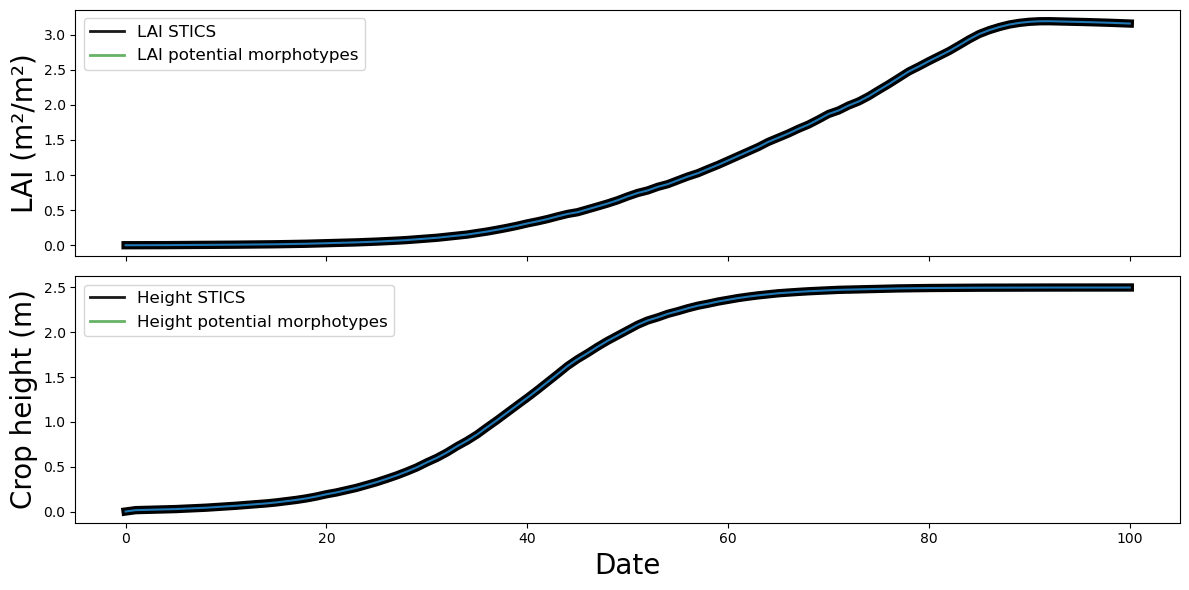

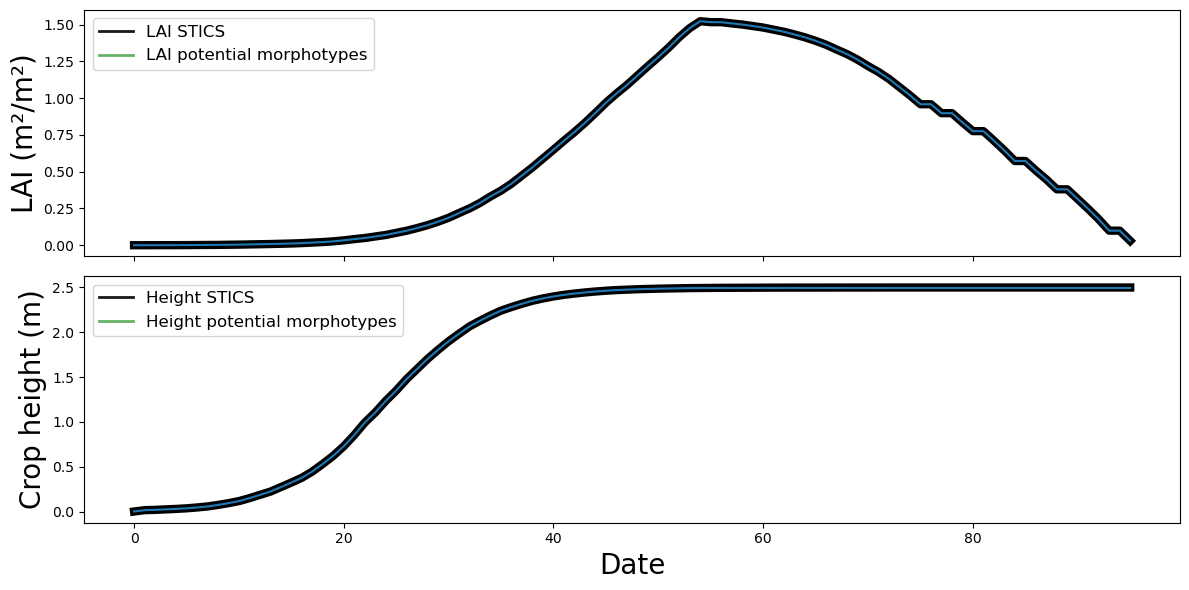

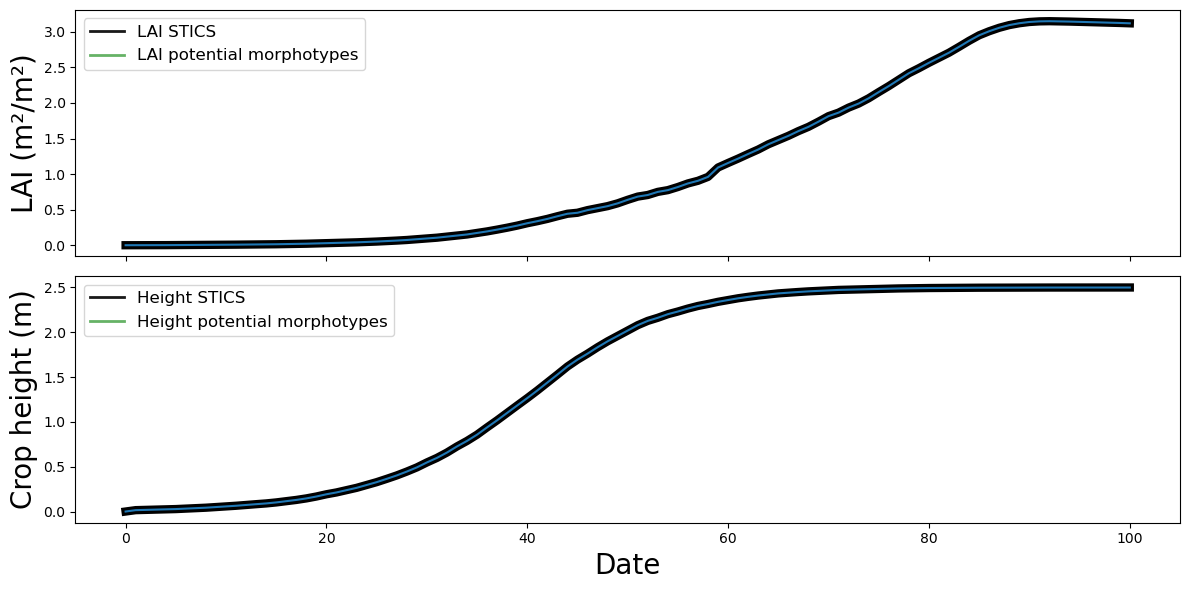

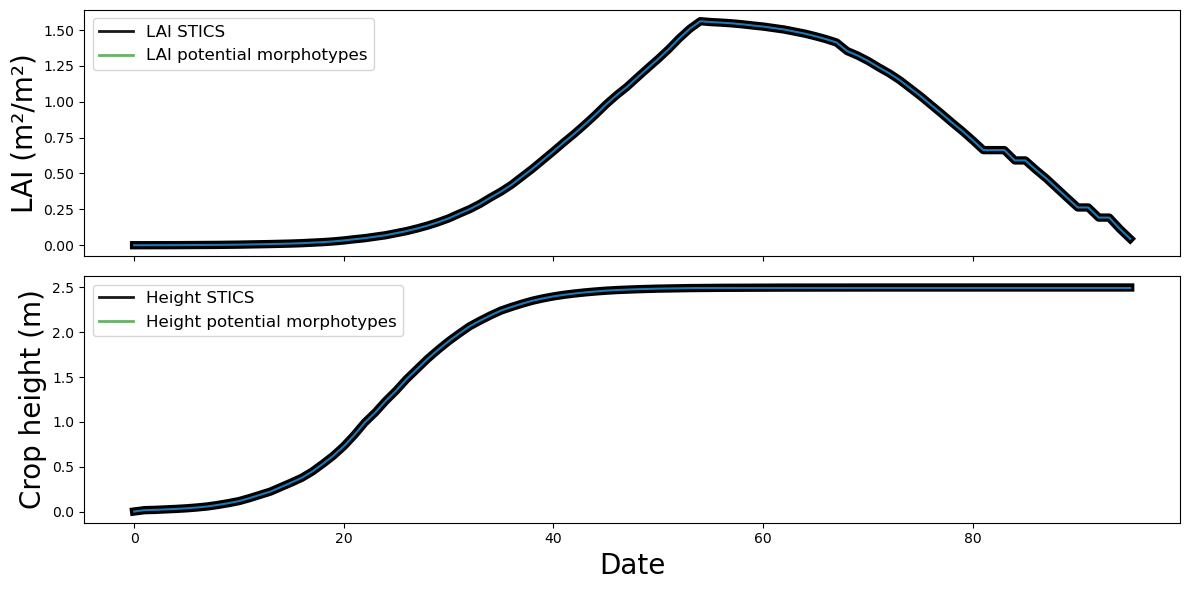

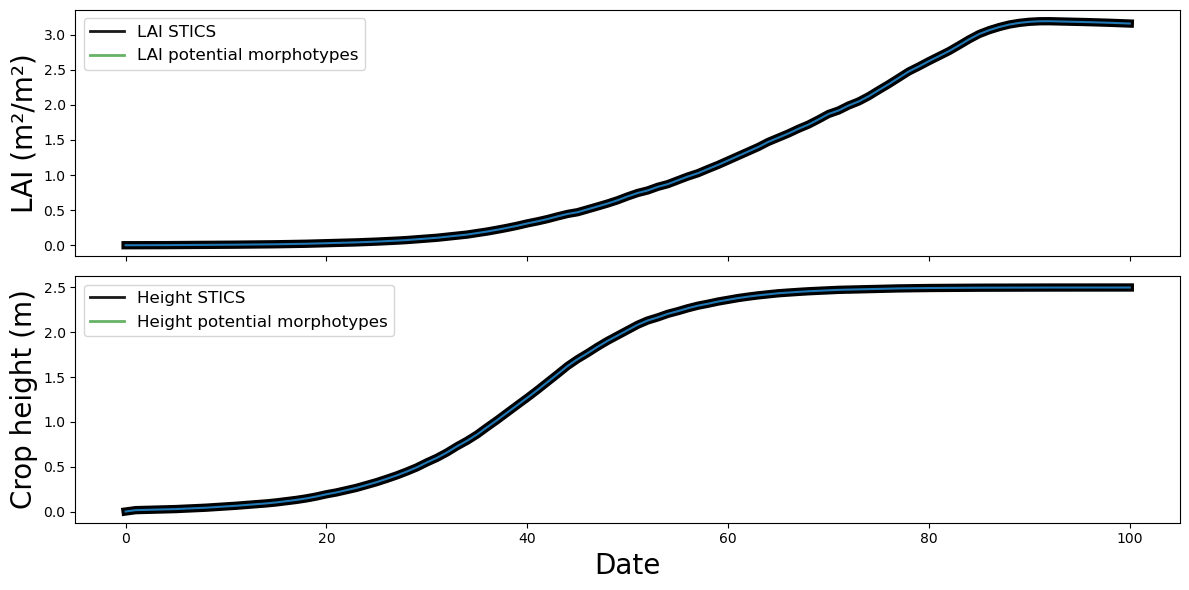

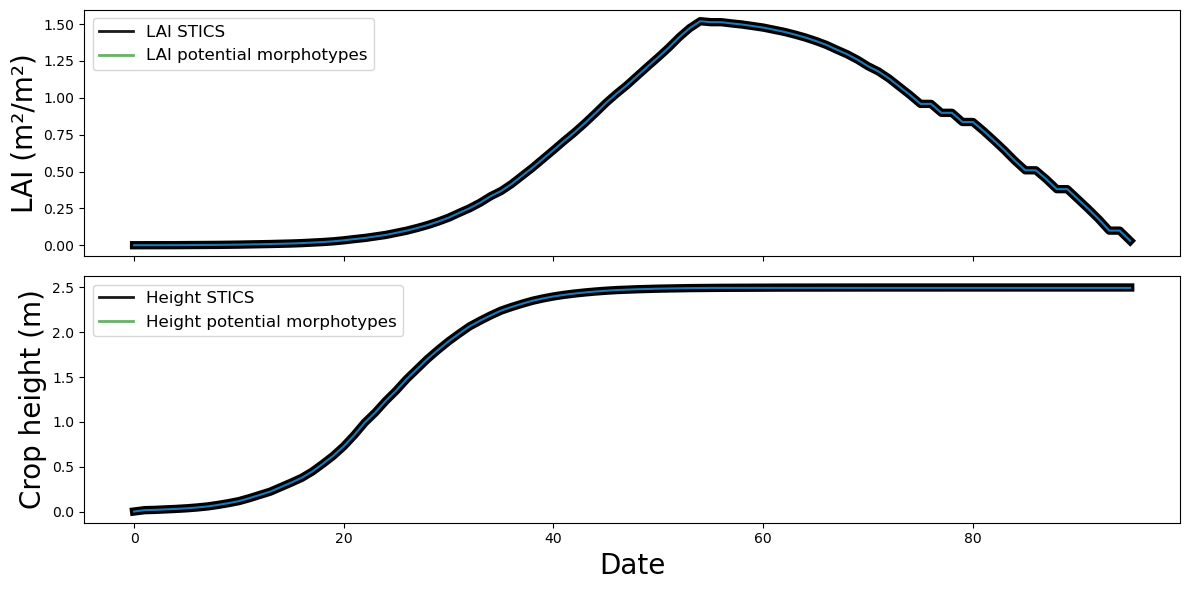

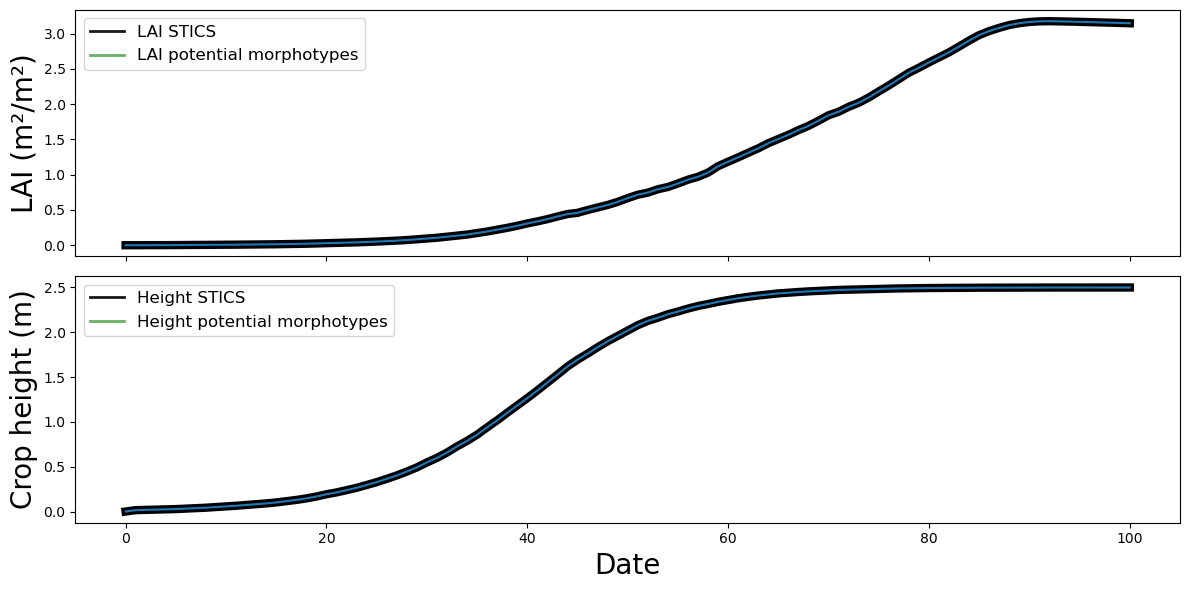

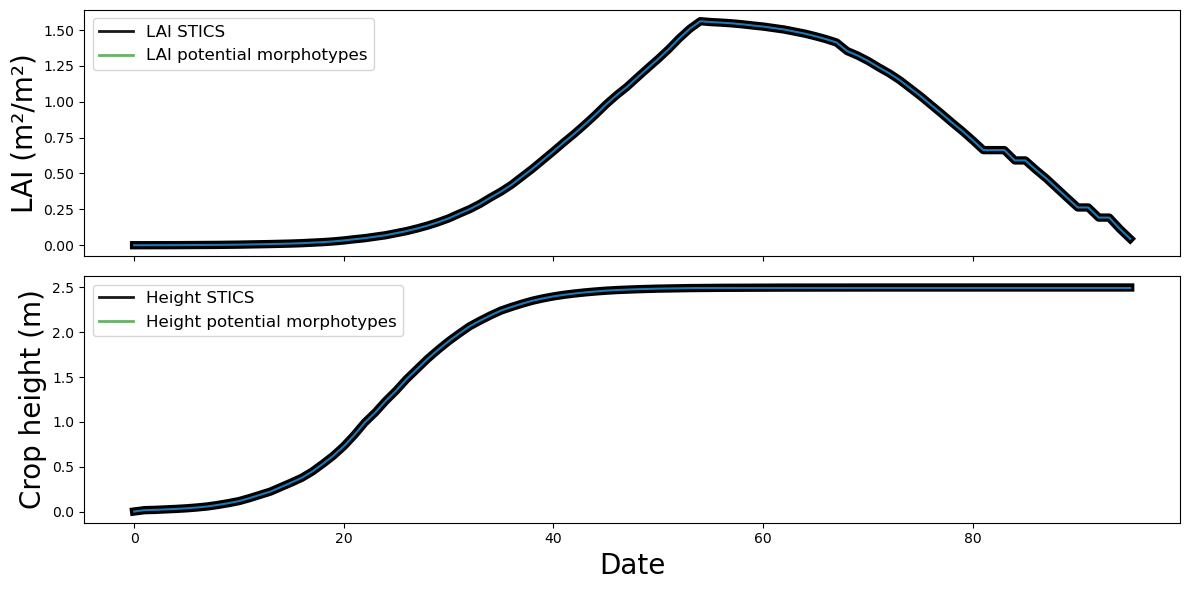

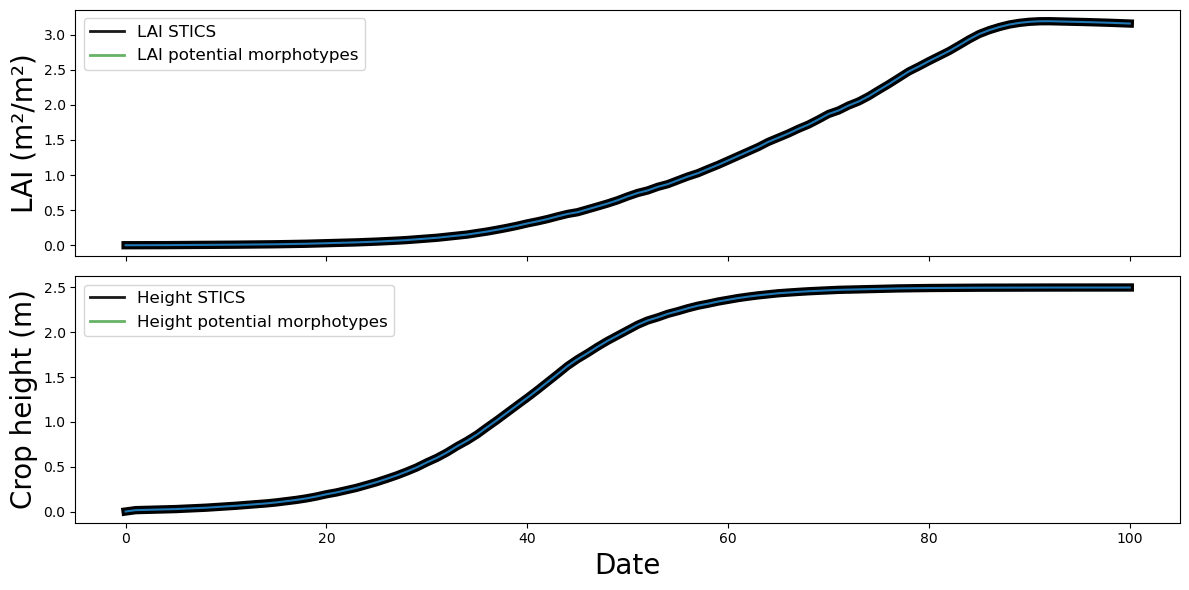

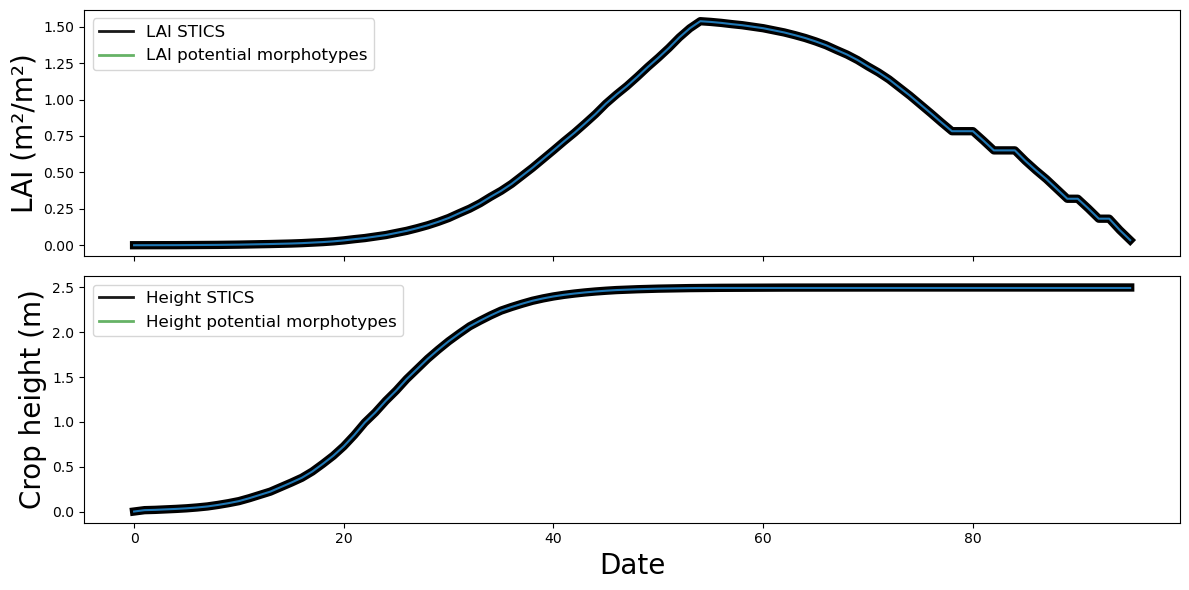

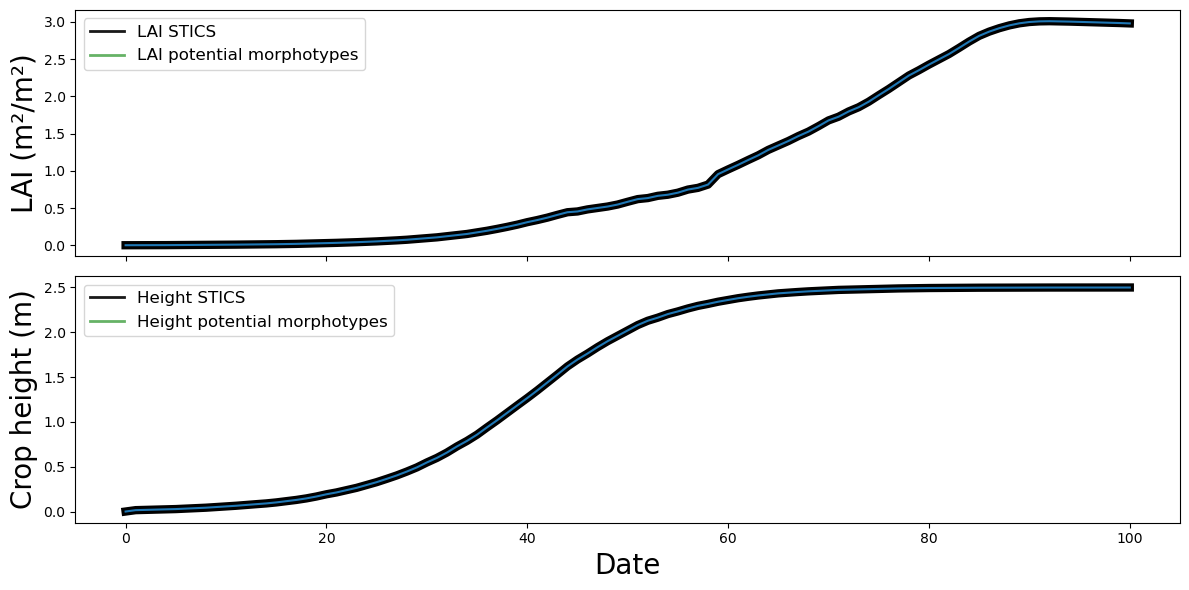

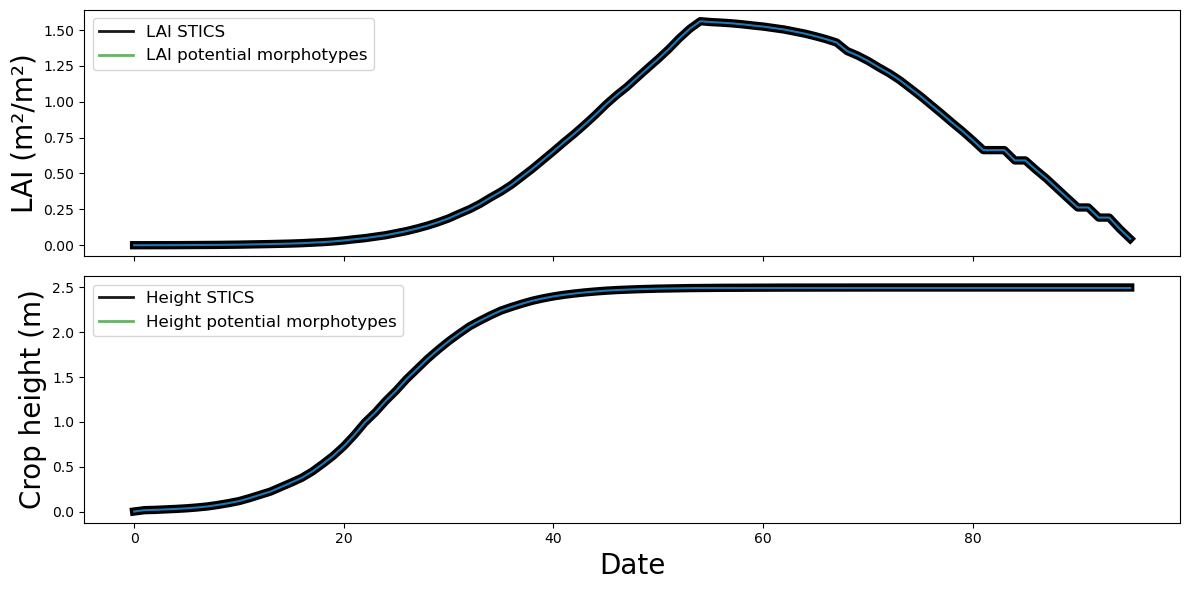

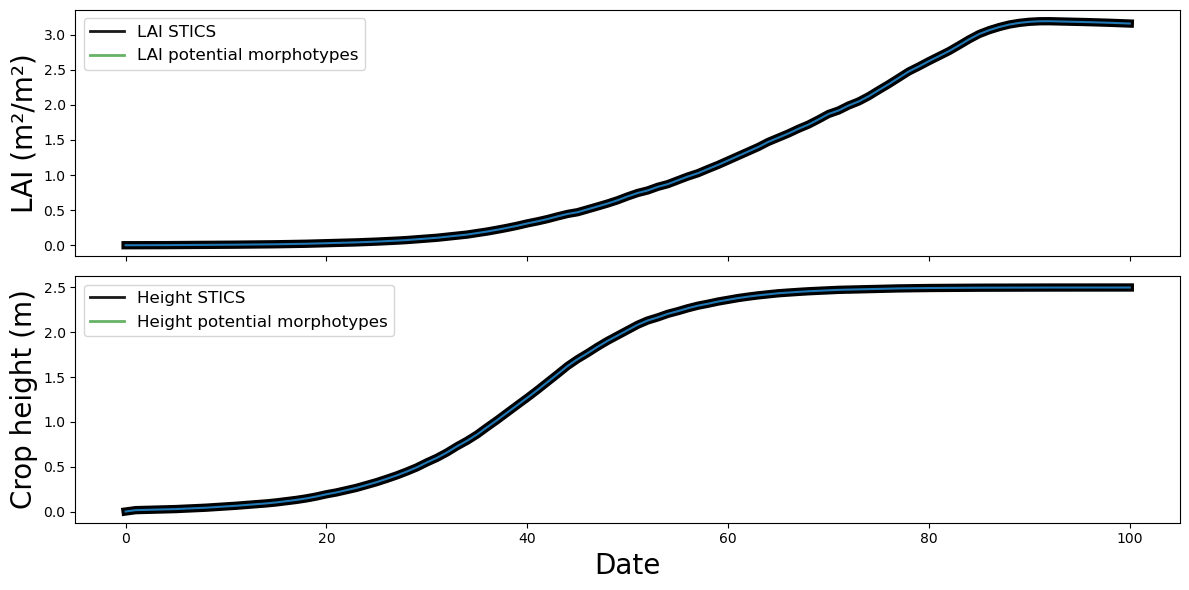

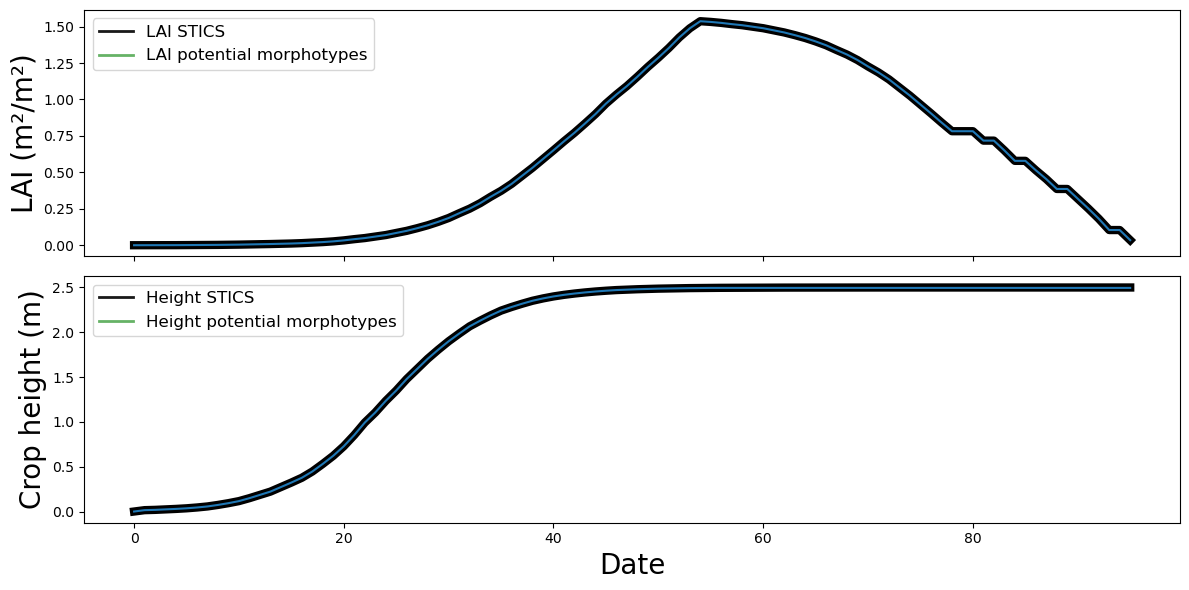

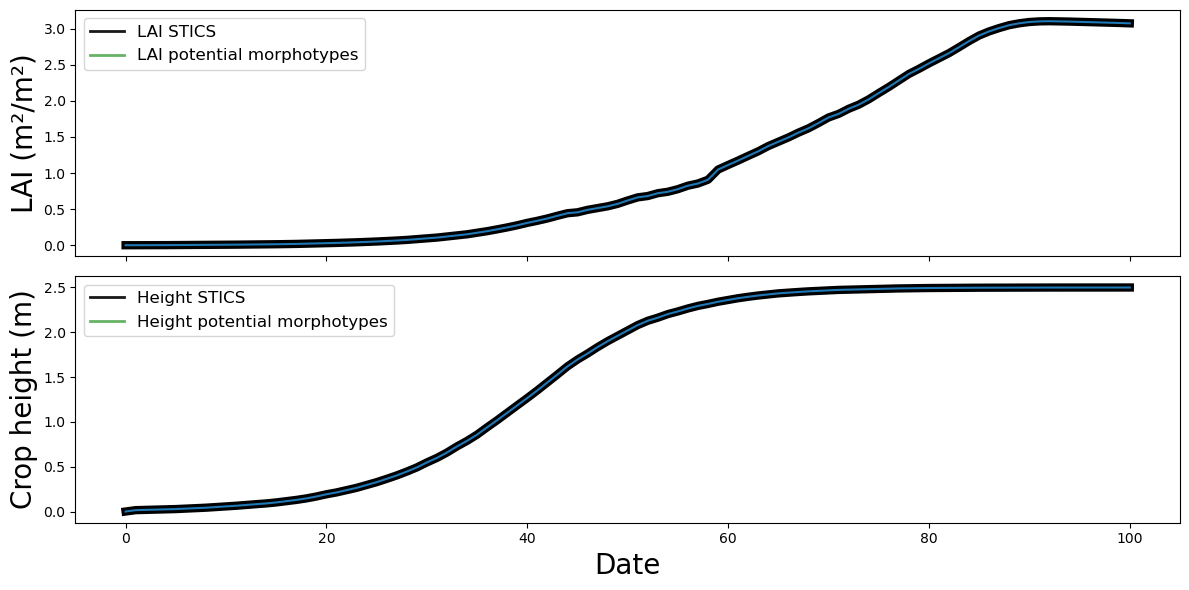

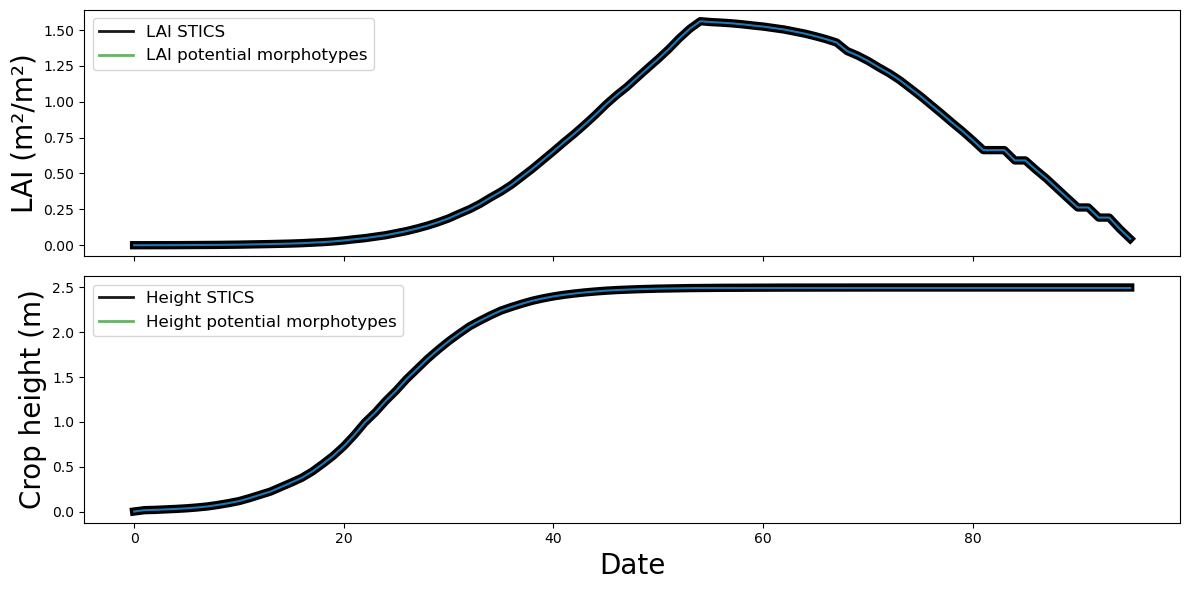

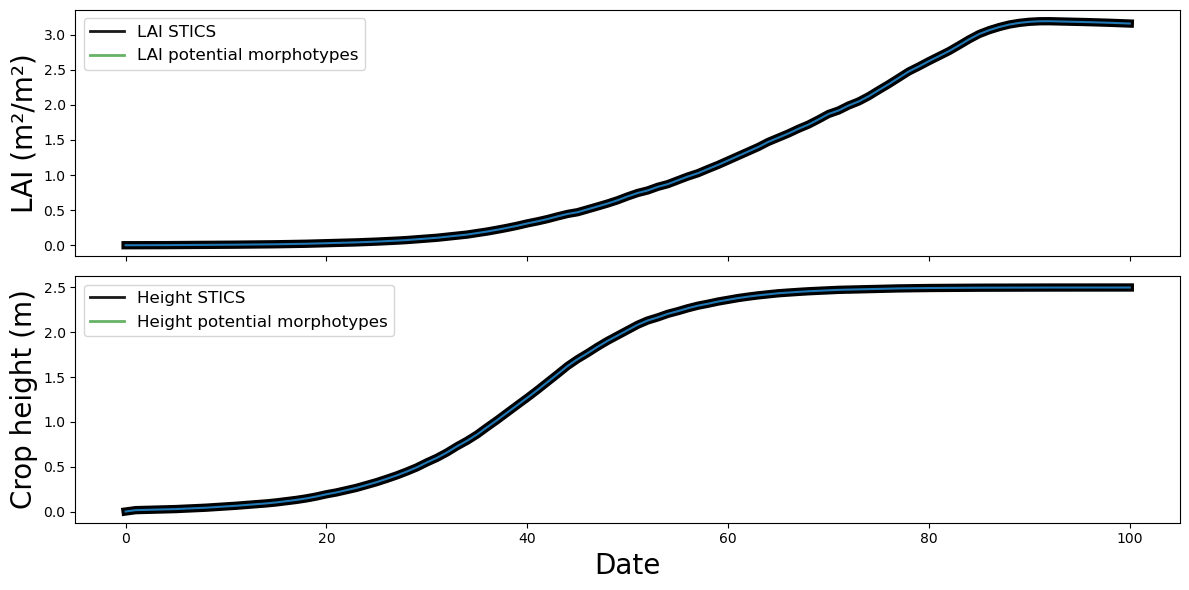

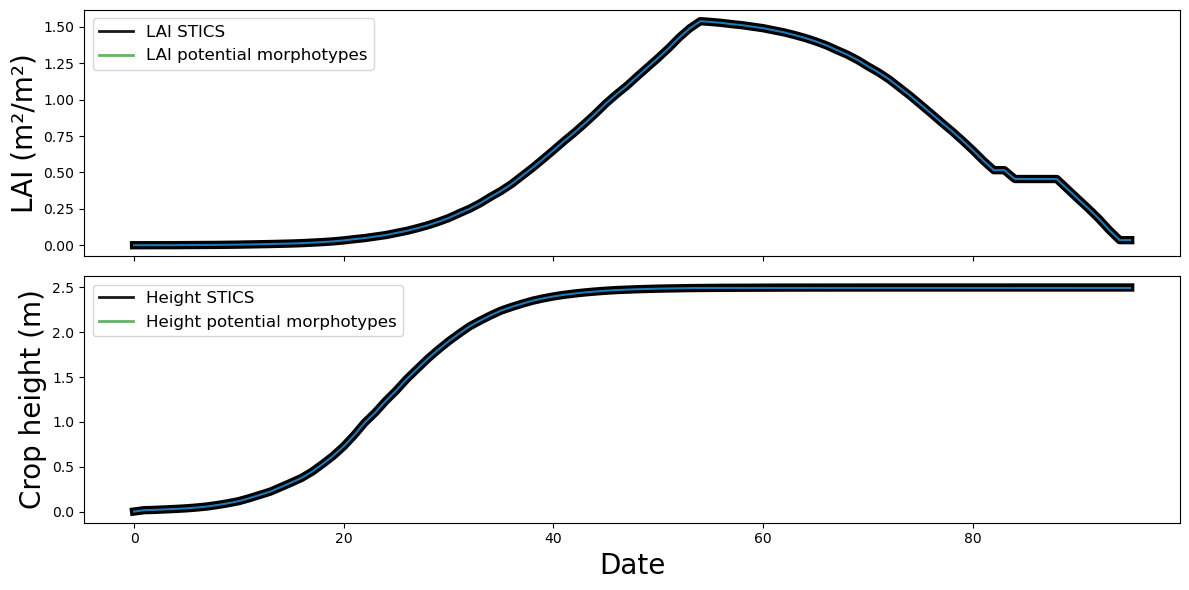

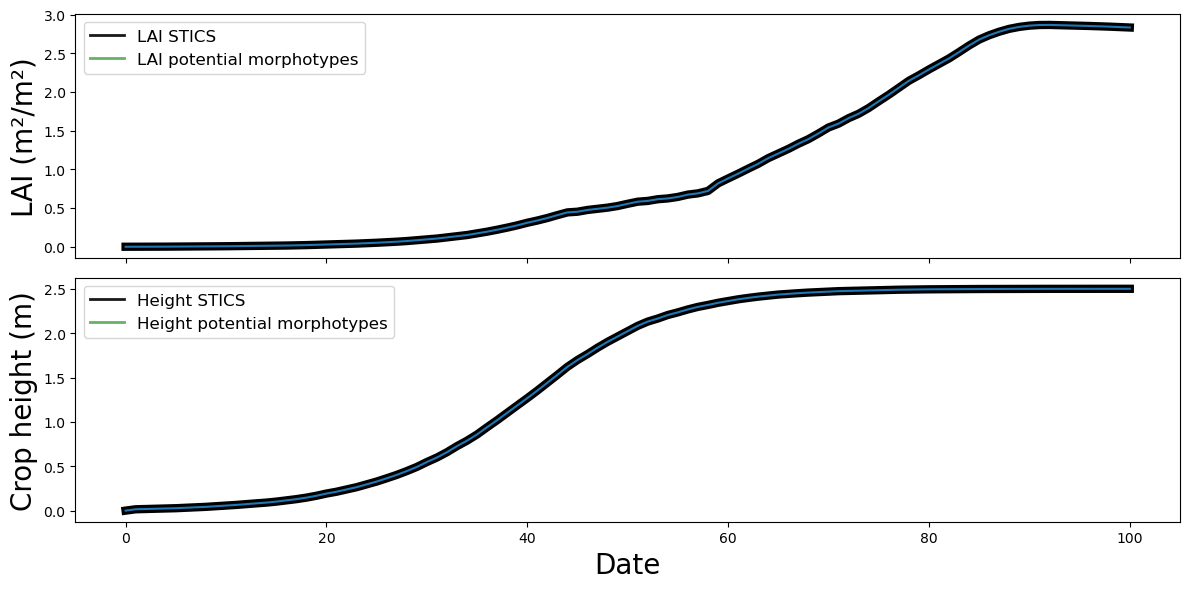

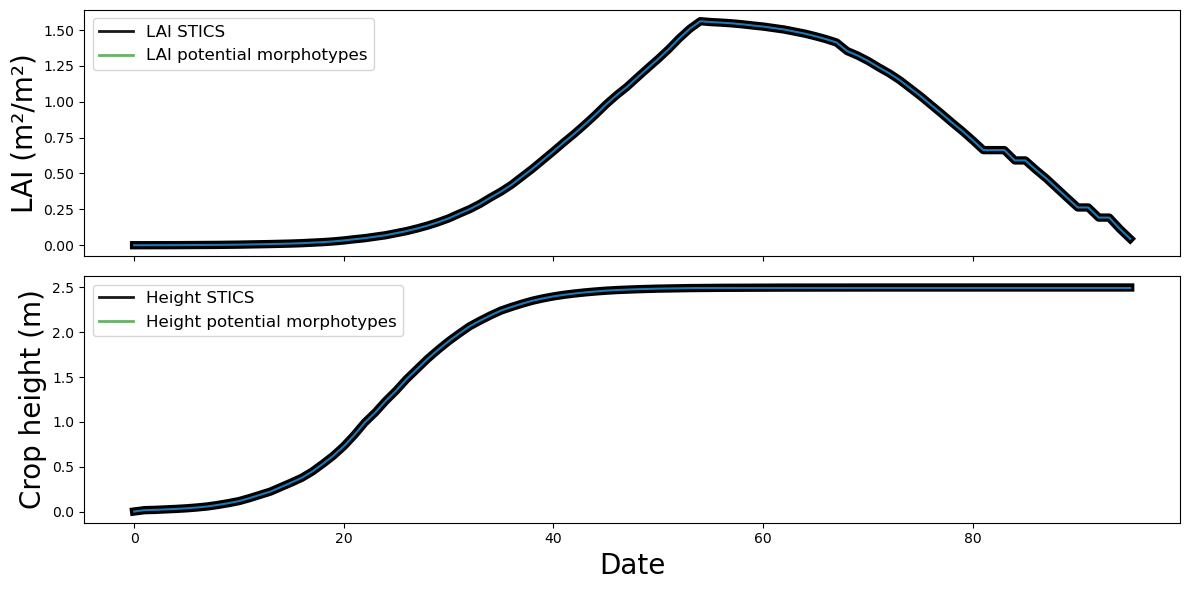

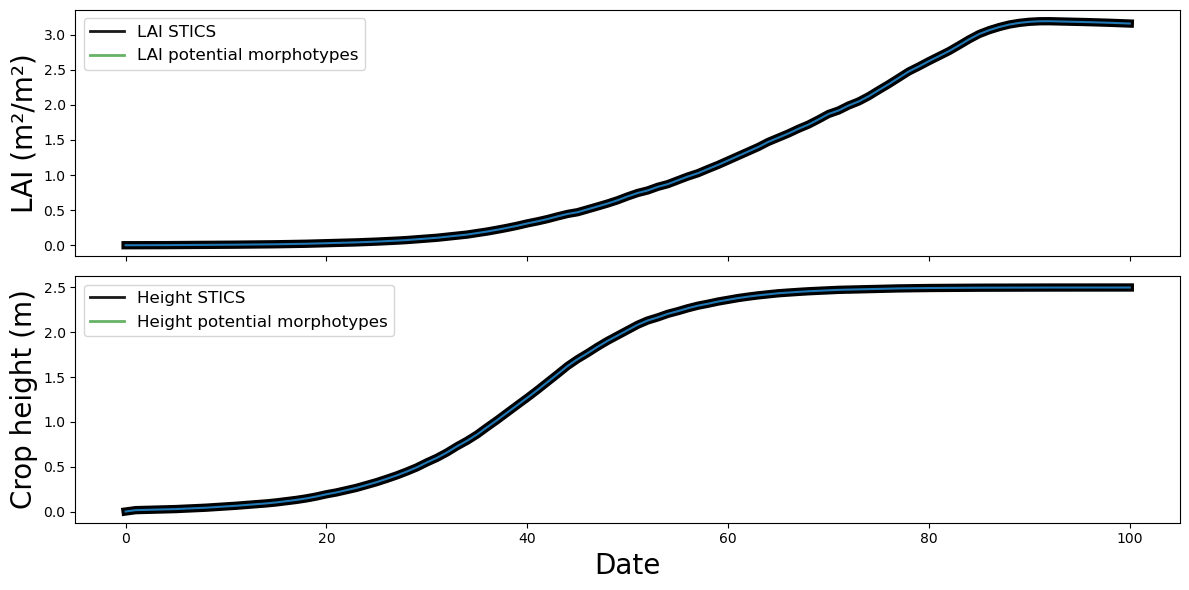

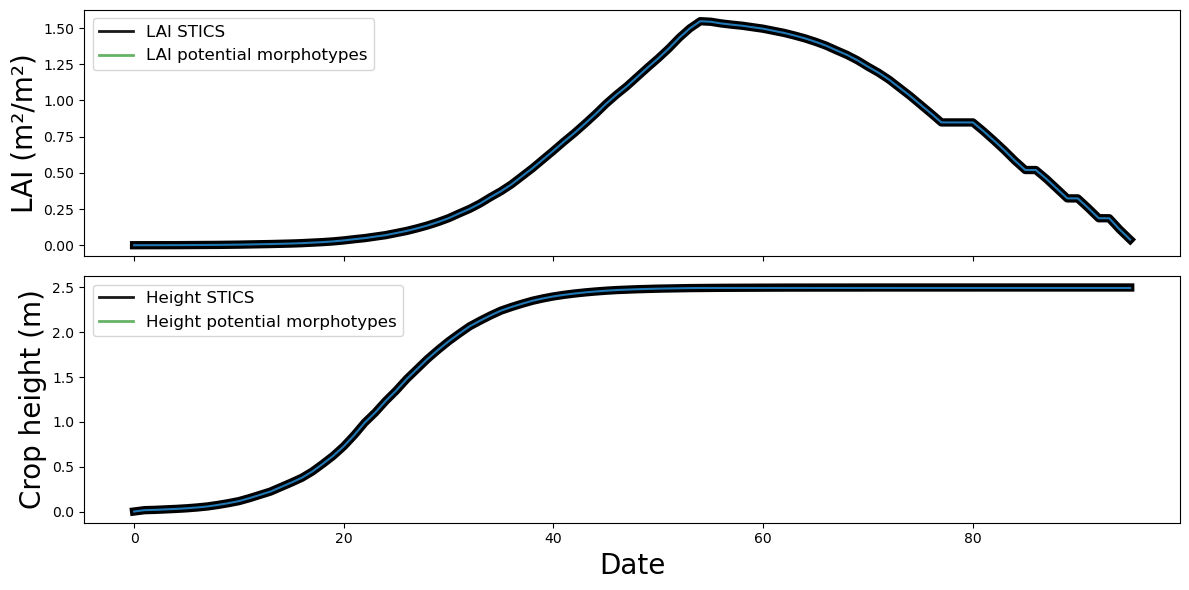

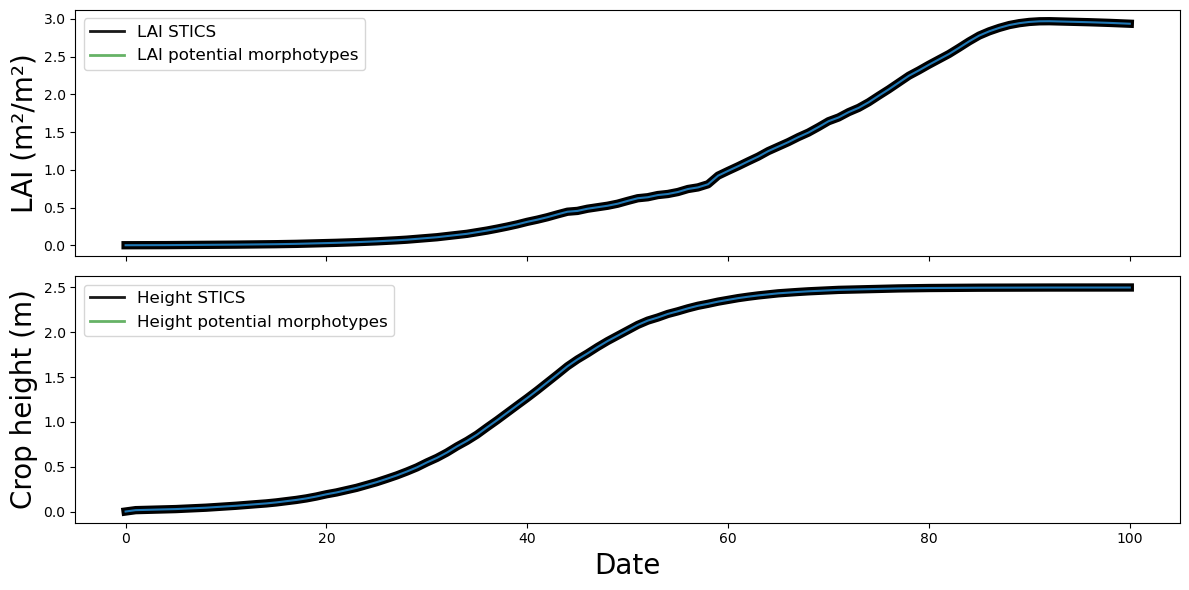

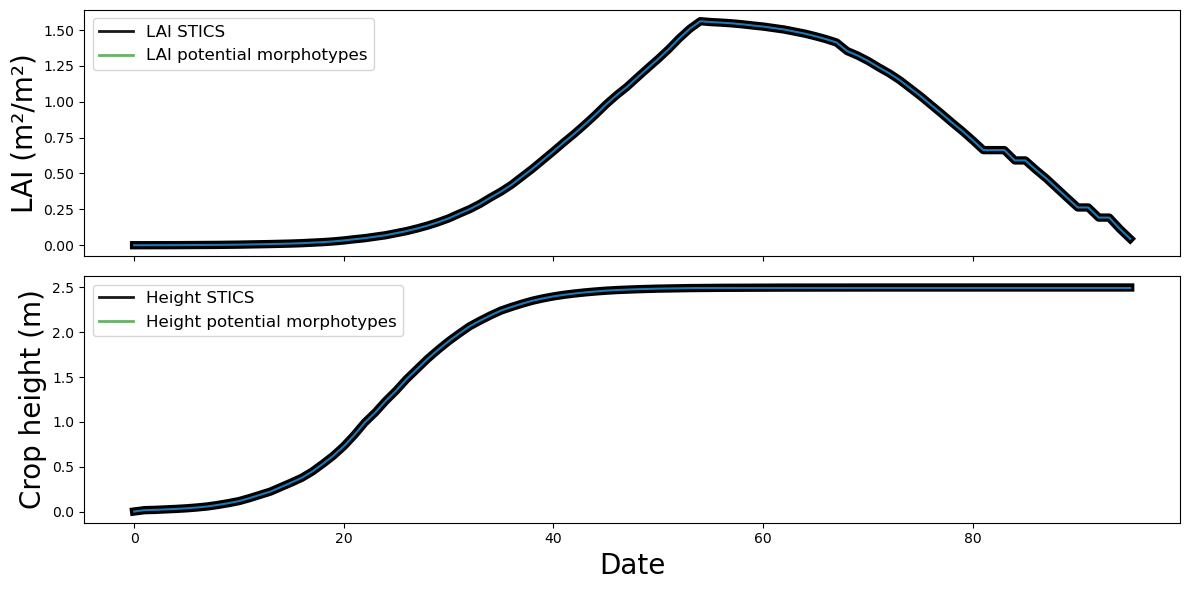

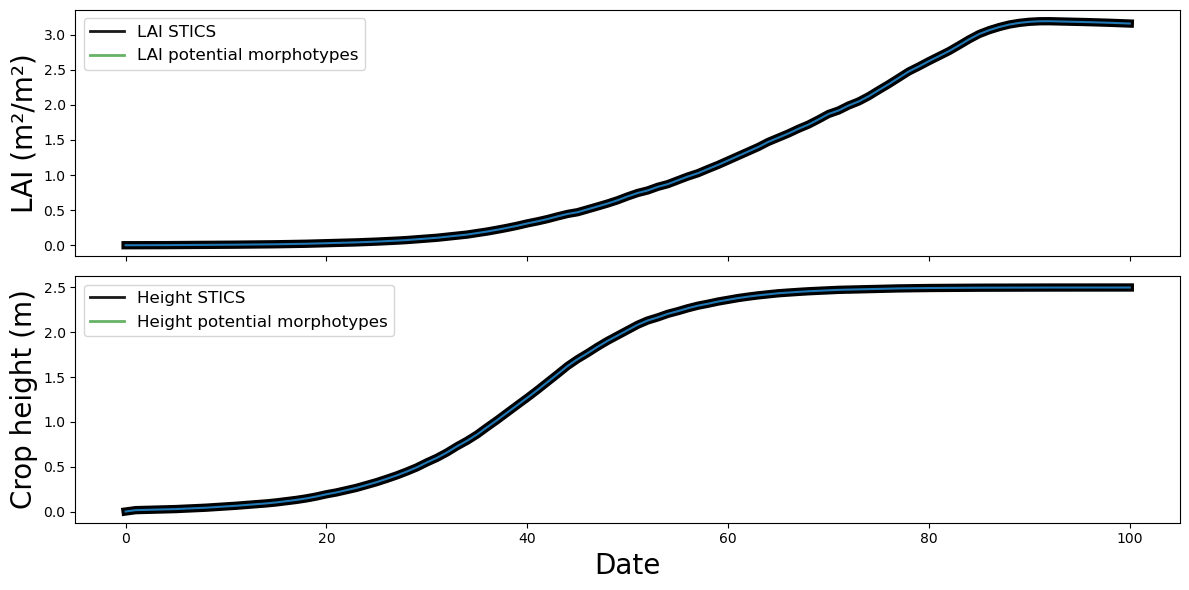

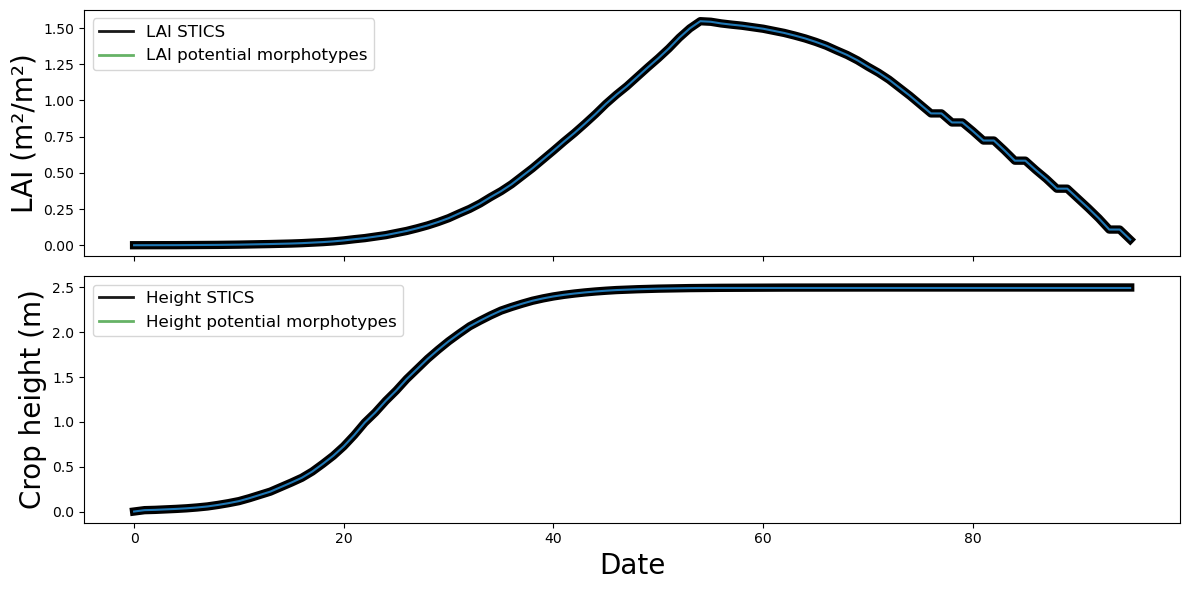

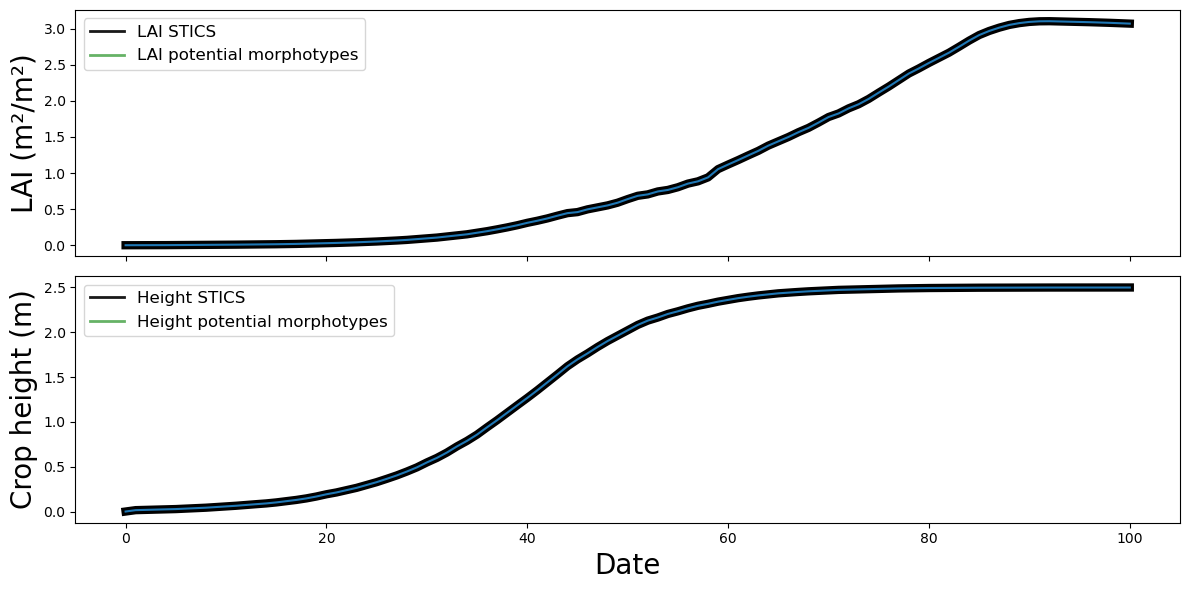

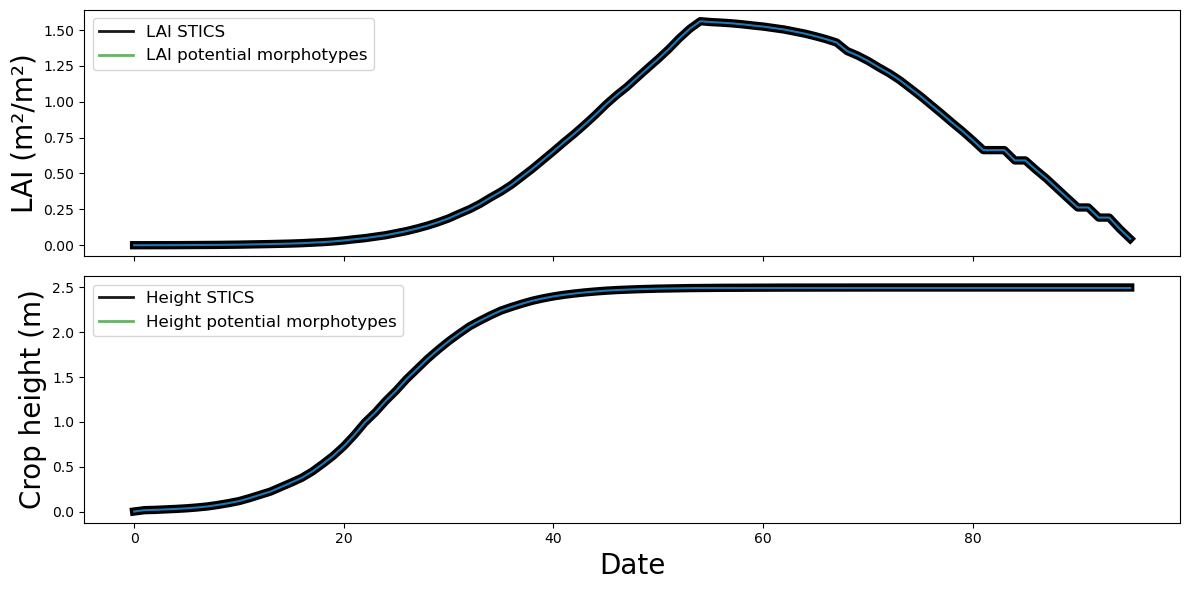

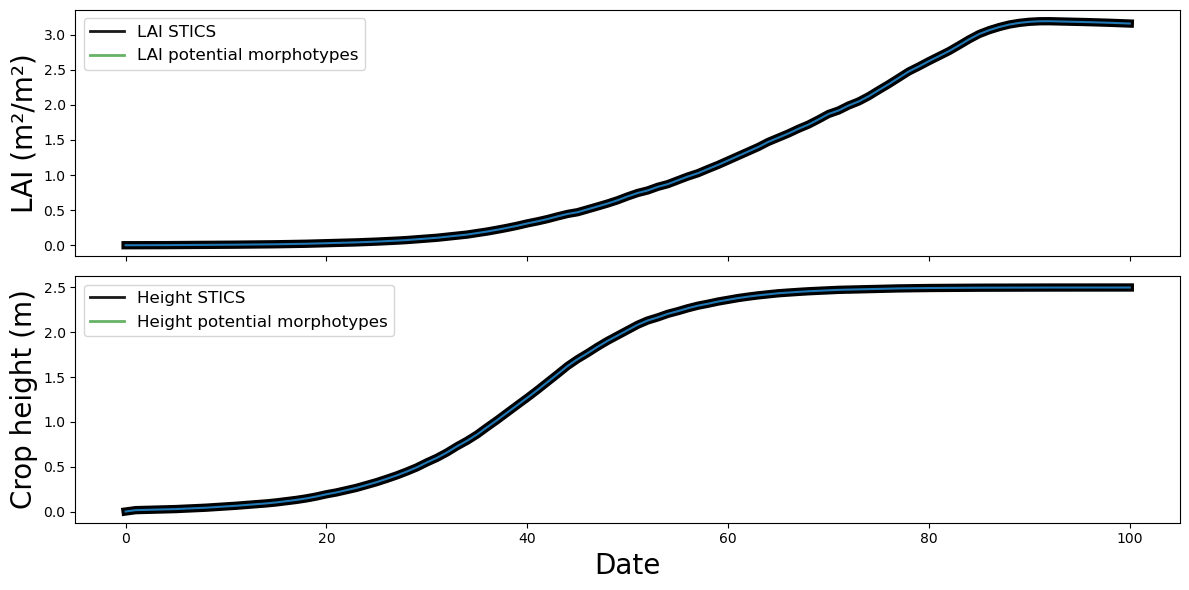

In [45]:
def plot_constained_vs_realized_IC(dates, la, H, leaf_area_plant, height_canopy, sen_leaf_area_plant, density, stics_color="orange", archicrop_color="green"):
    
    # conversion factor
    cf_cm = 100

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)  # 1 row, 2 columns
    axes[0].plot(dates, [(la-sen)*density/cf_cm**2 for la, sen in zip(leaf_area_plant, sen_leaf_area_plant)], color=stics_color, linewidth=6)
    axes[0].plot(dates, [a*density/cf_cm**2 for a in la]) # , color=archicrop_color, alpha=0.6)
    # axes[0].set_xticks(np.arange(0, len(dates)+1, (len(dates)+1)/8))
    axes[0].set_ylabel("LAI (m²/m²)", fontsize=20)

    legend_elements_lai = [
        Line2D([0], [0], color=stics_color, alpha=0.9, lw=2, label='LAI STICS'),
        Line2D([0], [0], color=archicrop_color, alpha=0.6, lw=2, label='LAI potential morphotypes')
    ]
    axes[0].legend(handles=legend_elements_lai, loc=2, prop={'size': 12})

    axes[1].plot(dates, [h/cf_cm for h in height_canopy], color=stics_color, linewidth=6)
    axes[1].plot(dates, [h/cf_cm for h in H]) #, color=archicrop_color, alpha=0.6)
    # axes[1].set_xticks(np.arange(0, len(dates)+1, (len(dates)+1)/8))
    axes[1].set_xlabel("Date", fontsize=20)
    axes[1].set_ylabel("Crop height (m)", fontsize=20)

    legend_elements_height = [
        Line2D([0], [0], color=stics_color, alpha=0.9, lw=2, label='Height STICS'),
        Line2D([0], [0], color=archicrop_color, alpha=0.6, lw=2, label='Height potential morphotypes')
    ]
    axes[1].legend(handles=legend_elements_height, loc=2, prop={'size': 12})

    # Adjust layout
    plt.tight_layout()

    # Save figure
    # plt.savefig(f"../figures/plot_constrained_vs_realized_IC.png", dpi=1000)

    # Show the plot
    plt.show()

for u,usm in enumerate(usms_str):
    for a,algo in enumerate(algos):
        for p,plant in enumerate(plants):
            plot_constained_vs_realized_IC(dates, realized_la[usm][algo][plant], realized_h[usm][algo][plant], leaf_area_plant[usm][algo][plant], height_canopy[usm][algo][plant], sen_leaf_area_plant[usm][algo][plant], density[usm][algo][plant], stics_color="black")

In [34]:
# Energy in Caribu : MJ.day-1
# Irradiance in Caribu : MJ.m[leaf]-2.day-1
# Incident PAR in STICS : MJ.m[soil]-2.day-1
# Absorbed PAR in STICS : MJ.m[soil]-2.day-1

In [61]:
colors = {
    'STICS' : {'Beer': 'darkorange',
                '2.5D': 'orange'},
    '3D' : {'Beer': 'darkgreen',
            '2.5D': 'green'}
}

linestyles = {
    'STICS' : {'Beer': 'dashed',
                '2.5D': 'solid'},
    '3D' : {'Beer': 'dashed',
            '2.5D': 'solid',
           'mixed': 'solid',
           'alternate': 'dotted',
           'strips': 'dashed'}
}

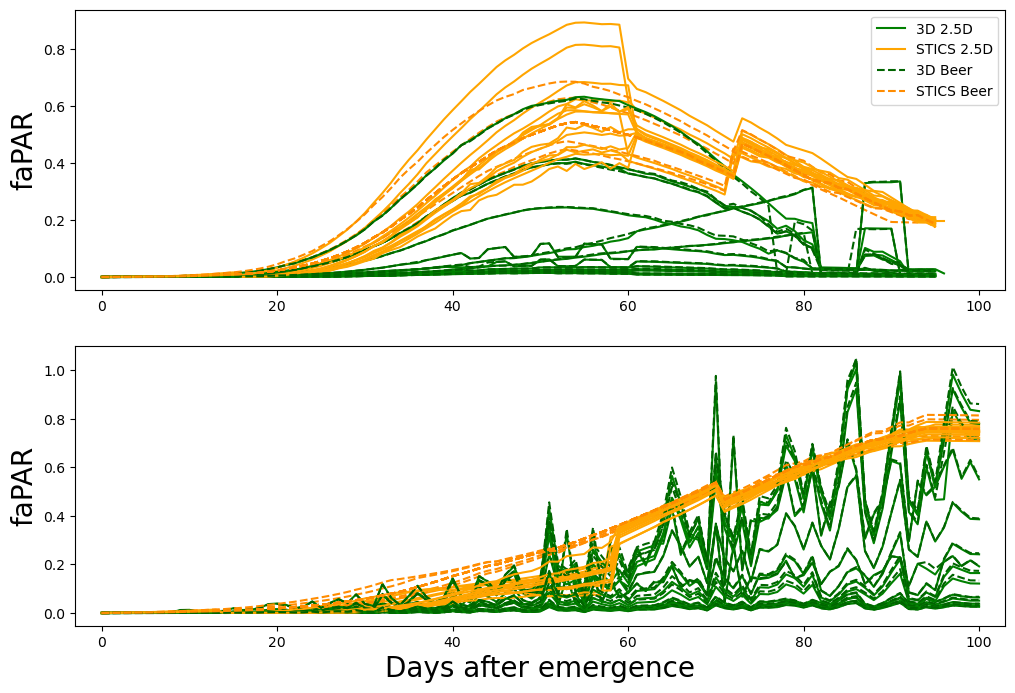

In [84]:
def plot_faPAR_algos_IC(dates, nrj_crop, par_stics, colors, linestyles):

    fig, ax = plt.subplots(2,1,figsize=(12, 8))
    i = 1
    for u,usm in nrj_crop.items():
        for a,algo in usm.items():
            j = 1
            np = 0
            for p,plant in algo.items():
                if i == 1 and j == 1:
                    ax[np].plot(dates, plant, color=colors['3D'][a], linestyle=linestyles['3D'][a], label=f'3D {a}') # label="ArchiCrop x Caribu")
                    ax[np].plot(dates, par_stics[u][a][p], color=colors['STICS'][a], linestyle=linestyles['STICS'][a], label=f"STICS {a}")
                else:
                    ax[np].plot(dates, plant, color=colors['3D'][a], linestyle=linestyles['3D'][a]) # label="ArchiCrop x Caribu")
                    ax[np].plot(dates, par_stics[u][a][p], color=colors['STICS'][a], linestyle=linestyles['STICS'][a])
                j += 1
                np = 1
        i += 1

    ax[1].set_xlabel("Days after emergence", fontsize=20) 
    ax[0].set_ylabel("faPAR", fontsize=20)
    ax[1].set_ylabel("faPAR", fontsize=20)
    ax[0].legend()

    ax[0].set_xlim(-3,103)
    ax[1].set_xlim(-3,103)

    plt.savefig(f"../figures/plot_faPAR_algos_IC.png", dpi=1000)

    plt.show()

plot_faPAR_algos_IC(dates, nrj_crop, par_stics, colors, linestyles)

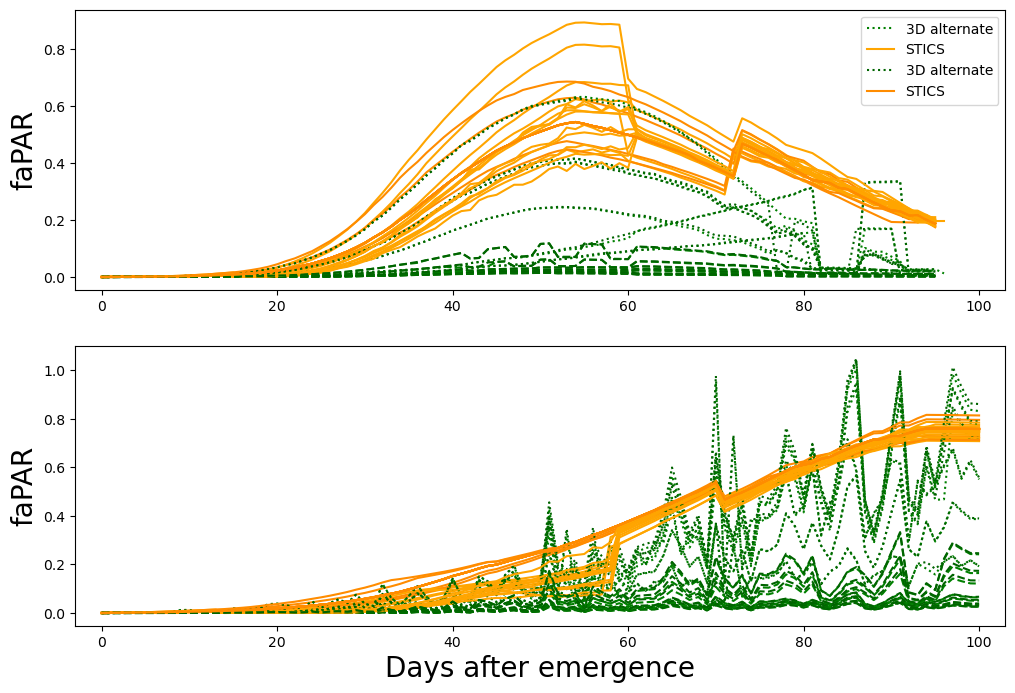

In [85]:
def plot_faPAR_design_IC(dates, nrj_crop, par_stics, colors, linestyles):

    fig, ax = plt.subplots(2,1,figsize=(12, 8))
    i = 1
    for u,usm in nrj_crop.items():
        for a,algo in usm.items():
            j = 1
            np = 0
            if doe_adapt[u][a]["nb_rows_1"] == 0:
                design = "mixed"
            elif doe_adapt[u][a]["nb_rows_1"] == 1:
                design = "alternate"
            else: 
                design = "strips"
            for p,plant in algo.items():
                if i == 1 and j == 1:
                    ax[np].plot(dates, plant, color=colors['3D'][a], linestyle=linestyles['3D'][design], label=f'3D {design}') # label="ArchiCrop x Caribu")
                    ax[np].plot(dates, par_stics[u][a][p], color=colors['STICS'][a], linestyle='solid', label=f"STICS")
                else:
                    ax[np].plot(dates, plant, color=colors['3D'][a], linestyle=linestyles['3D'][design]) # label="ArchiCrop x Caribu")
                    ax[np].plot(dates, par_stics[u][a][p], color=colors['STICS'][a], linestyle='solid')
                j += 1
                np = 1
        i += 1

    ax[1].set_xlabel("Days after emergence", fontsize=20) 
    ax[0].set_ylabel("faPAR", fontsize=20)
    ax[1].set_ylabel("faPAR", fontsize=20)
    ax[0].legend()

    ax[0].set_xlim(-3,103)
    ax[1].set_xlim(-3,103)

    plt.savefig(f"../figures/plot_faPAR_design_IC.png", dpi=1000)

    plt.show()

plot_faPAR_design_IC(dates, nrj_crop, par_stics, colors, linestyles)

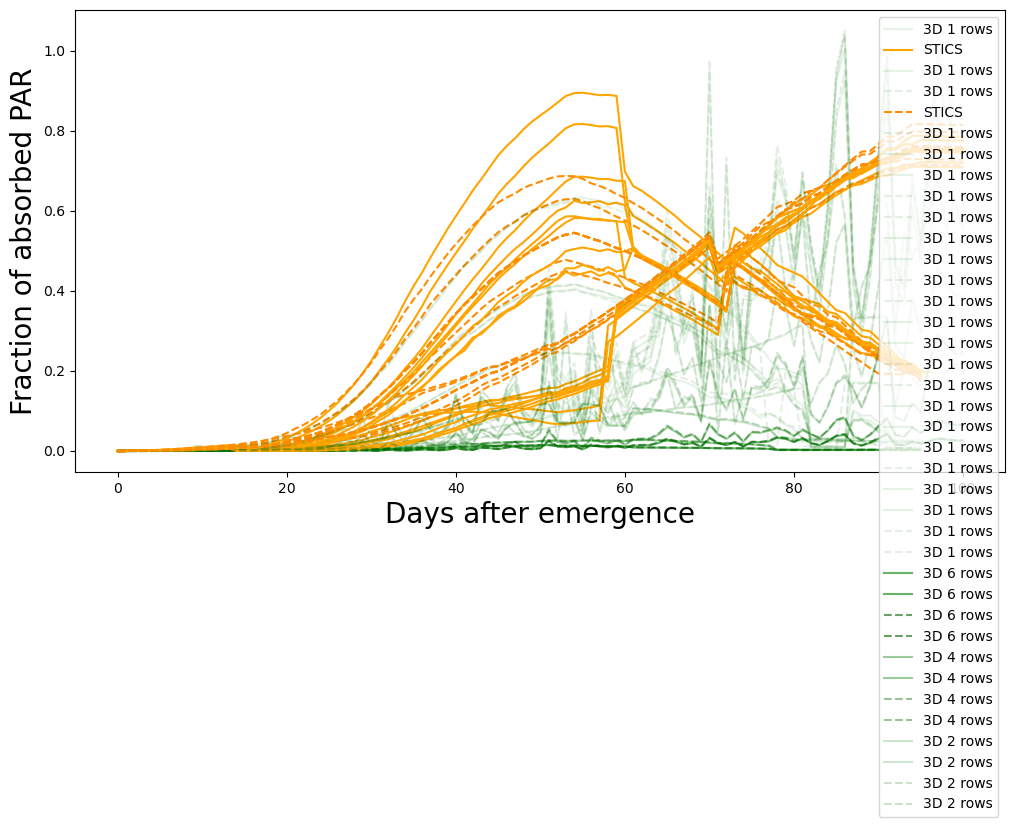

In [72]:
def plot_faPAR_nrows_IC(dates, nrj_crop, par_stics, colors, linestyles):

    # Plotting the envelope along with individual curves for context
    fig, ax = plt.subplots(figsize=(12, 6))
    i = 1
    for u,usm in nrj_crop.items():
        for a,algo in usm.items():
            j = 1
            nrows1 = doe_adapt[u][a]["nb_rows_1"]
            nrows2 = doe_adapt[u][a]["nb_rows_2"]
            if nrows1 > 0 and nrows1 == nrows2:
                for p,plant in algo.items():
                    if i == 1 and j == 1:
                        ax.plot(dates, plant, color=colors['3D'][a], linestyle=linestyles['3D'][a], alpha=0.1*nrows1, label=f'3D {nrows1} rows') # label="ArchiCrop x Caribu")
                        ax.plot(dates, par_stics[u][a][p], color=colors['STICS'][a], linestyle=linestyles['STICS'][a], label=f"STICS")
                    else:
                        ax.plot(dates, plant, color=colors['3D'][a], linestyle=linestyles['3D'][a], alpha=0.1*nrows1, label=f'3D {nrows1} rows') # label="ArchiCrop x Caribu")
                        ax.plot(dates, par_stics[u][a][p], color=colors['STICS'][a], linestyle=linestyles['STICS'][a])
                    j += 1
        i += 1

    # Labels and legend
    # ax.set_xticks(np.arange(0, len(dates)+1, (len(dates)+1)/8))
    ax.set_xlabel("Days after emergence", fontsize=20) 
    ax.set_ylabel("Fraction of absorbed PAR", fontsize=20)
    ax.legend()

    # Save figure
    plt.savefig(f"../figures/plot_faPAR_nrows_IC.png", dpi=1000)

    plt.show()

plot_faPAR_nrows_IC(dates, nrj_crop, par_stics, colors, linestyles)

In [38]:
"""
# vertical light interception
cs, ei, df = illuminate(scene, scene_unit='cm')
cs.plot(ei)


# diffuse light interception
sources = skys.sky_sources()
cs, ei, df = illuminate(scene, light=sources, scene_unit='cm')
cs.plot(ei)

# get score per plant
def score(res):
    return pd.Series({'ei':(res.Ei*res.area).sum() / res.area.sum(),
                              'area': res.area.sum()})
df['nump']=nump
df.groupby('nump').apply(score)
"""

"\n# vertical light interception\ncs, ei, df = illuminate(scene, scene_unit='cm')\ncs.plot(ei)\n\n\n# diffuse light interception\nsources = skys.sky_sources()\ncs, ei, df = illuminate(scene, light=sources, scene_unit='cm')\ncs.plot(ei)\n\n# get score per plant\ndef score(res):\n    return pd.Series({'ei':(res.Ei*res.area).sum() / res.area.sum(),\n                              'area': res.area.sum()})\ndf['nump']=nump\ndf.groupby('nump').apply(score)\n"